In [2]:
using LinearAlgebra
using Distributions
using FileIO
import JLD2
using DataFrames
using CairoMakie

In [3]:
using Revise
using Newtrinos
#using Newtrinos.osc

Scans NN

In [4]:
#NNATURALNESS 

using Revise
using Newtrinos

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NND(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO)),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   katrin= Newtrinos.katrin.configure(physics),
);

par= Newtrinos.get_params(experiments)

matrix=Newtrinos.osc.get_matrices(osc_cfg.flavour)(par)

[ Info: Loading Katrin data


(ComplexF64[-0.8168935499694263 + 0.0im -0.5437108972831824 + 0.0im … -0.05415481330424365 + 0.0im -0.007734335334724904 + 0.012045513595371924im; 0.40914300190845243 + 0.07600818142539172im -0.5089043221386129 + 0.05058979413561212im … -0.050688001091847346 + 0.005038855888678794im -0.07379132405527435 + 0.0im; … ; -0.009318757440194933 - 0.0017311839695892956im 0.01159094965856872 - 0.0011522475474348964im … -0.22494357424949074 + 0.02236147074874111im -0.3274716663519327 + 0.0im; 0.00848377502254429 - 0.0015036266758122363im -0.014839528942619739 - 0.0010007891592673215im … 0.2879881958648625 + 0.019422143757592047im -0.2844268094836078 + 0.0im], [0.0, 7.737972471822558e-5, 0.0025436657715142592, 0.0001974162104815563, 0.00042345034169239375, 0.007627725440045777, 0.00039457509809140526, 0.0007690698716724589, 0.012705158272662213, 0.0005910461804015519  …  0.03297253584705333, 0.001380966079715625, 0.0024982132624597163, 0.038107685222430736, 0.0015849618426020157, 0.00285581783479

In [ ]:

all_priors = Newtrinos.get_priors(experiments)
N=200
par= merge(par, (N =N,))
  
vars_to_scan = (r=31, m₀ =31)  

modified_priors = (
    N = all_priors.N,
    m₀ = LogUniform(1e-6, 1e-1),
    r = LogUniform(1e-8, 1),
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)
    

likelihood_NN = Newtrinos.generate_likelihood(experiments);

result = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, par)

JLD2.@save "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_Nr_N=$(N)_η=1+1N_NND_NO.jld2" result


Number of threads: 4
Total points to compute: 961


Progress: 100%|█████████████████████████████████████████| Time: 0:01:11


TIMING STATISTICS:
  Min time per point: 50.4 ms
  Max time per point: 5487.9 ms
  Mean time per point: 286.7 ms
  Median time per point: 214.0 ms
TOTAL TIME:
  Total seconds: 275.54
  Total minutes: 4.59


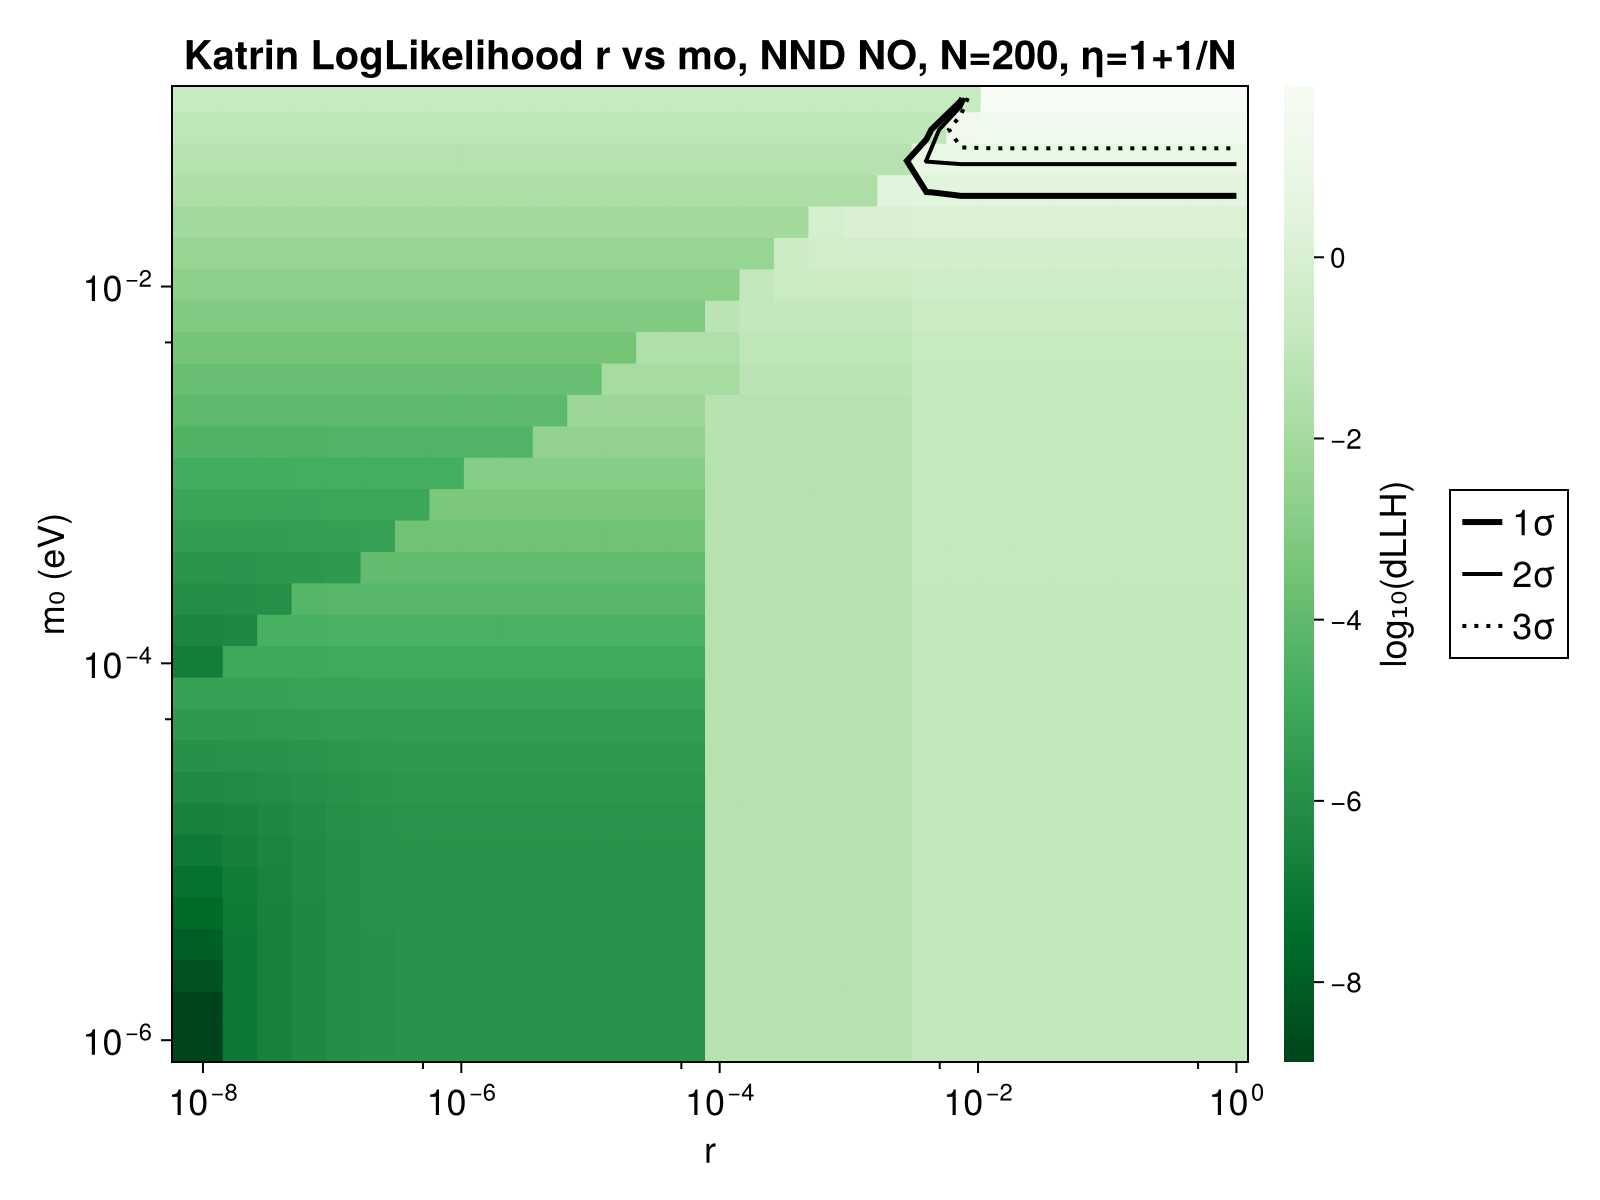

In [ ]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result; title="Katrin LogLikelihood r vs mo, NND NO, N=$N, η=1+1/N", log=3, mass=2, log_colormap=true)
display("image/png", img)
save("/home/sofialon/Newtrinos.jl/plots_fix/plots_new/katrin_rm0_NND_NO_N$N.png", img)

In [ ]:

all_priors = Newtrinos.get_priors(experiments)

m0=0.01

p= merge(par, (m₀ =m0,))
  
vars_to_scan = (r=31, N=31)  

modified_priors = (
    N = DiscreteUniform(2, 200),
    m₀ =all_priors.m₀,
    r = LogUniform(1e-8,1),
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)
    

likelihood_NN = Newtrinos.generate_likelihood(experiments);

result= Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, p)


JLD2.@save "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_Nr_m0=$(m0)_η=1+1N_NND_NO.jld2" result

Number of threads: 4
Total points to compute: 961


Progress: 100%|█████████████████████████████████████████| Time: 0:00:18


TIMING STATISTICS:
  Min time per point: 0.0 ms
  Max time per point: 3885.9 ms
  Mean time per point: 45.1 ms
  Median time per point: 31.5 ms
TOTAL TIME:
  Total seconds: 43.36
  Total minutes: 0.72


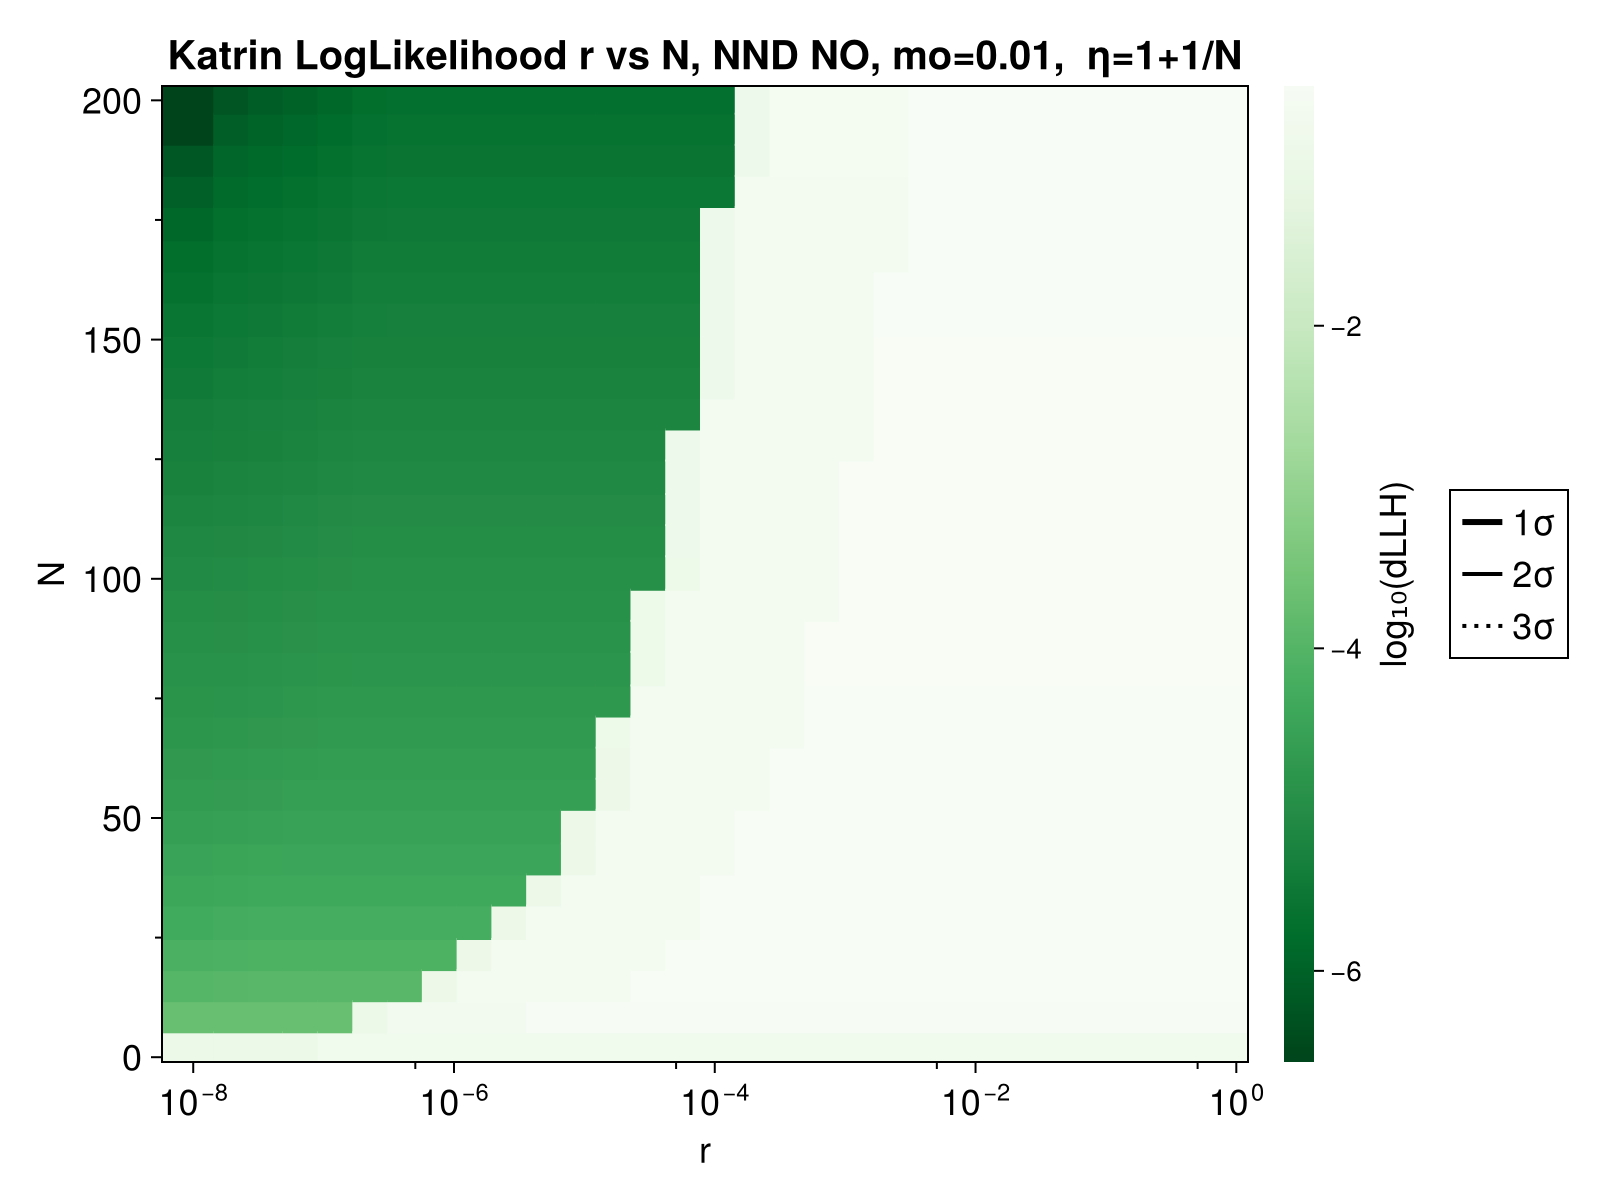

In [ ]:

#plot and save the image
using CairoMakie
img = CairoMakie.plot(result; title="Katrin LogLikelihood r vs N, NND NO, mo=$m0,  η=1+1/N", log=1, mass=0, log_colormap=true)
display("image/png", img)
save("/home/sofialon/Newtrinos.jl/plots_fix/plots_new/katrin_Nr_m0=$(m0)_η=1+1_N_NND_NO.png", img)

In [ ]:

all_priors = Newtrinos.get_priors(experiments)

r=1

par= merge(par, (r =r,))
  
vars_to_scan = ( m₀ =31, N=31)  

modified_priors = (
    N = DiscreteUniform(2, 100),
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)
    

likelihood_NN = Newtrinos.generate_likelihood(experiments);

result = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, par)

JLD2.@save "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_m0N_r=$(r)_η=1+1N_NND_NO.jld2" result


Number of threads: 4
Total points to compute: 961


Progress: 100%|█████████████████████████████████████████| Time: 0:00:02

TIMING STATISTICS:
  Min time per point: 0.0 ms
  Max time per point: 60.6 ms
  Mean time per point: 5.7 ms
  Median time per point: 4.4 ms
TOTAL TIME:
  Total seconds: 5.51
  Total minutes: 0.09


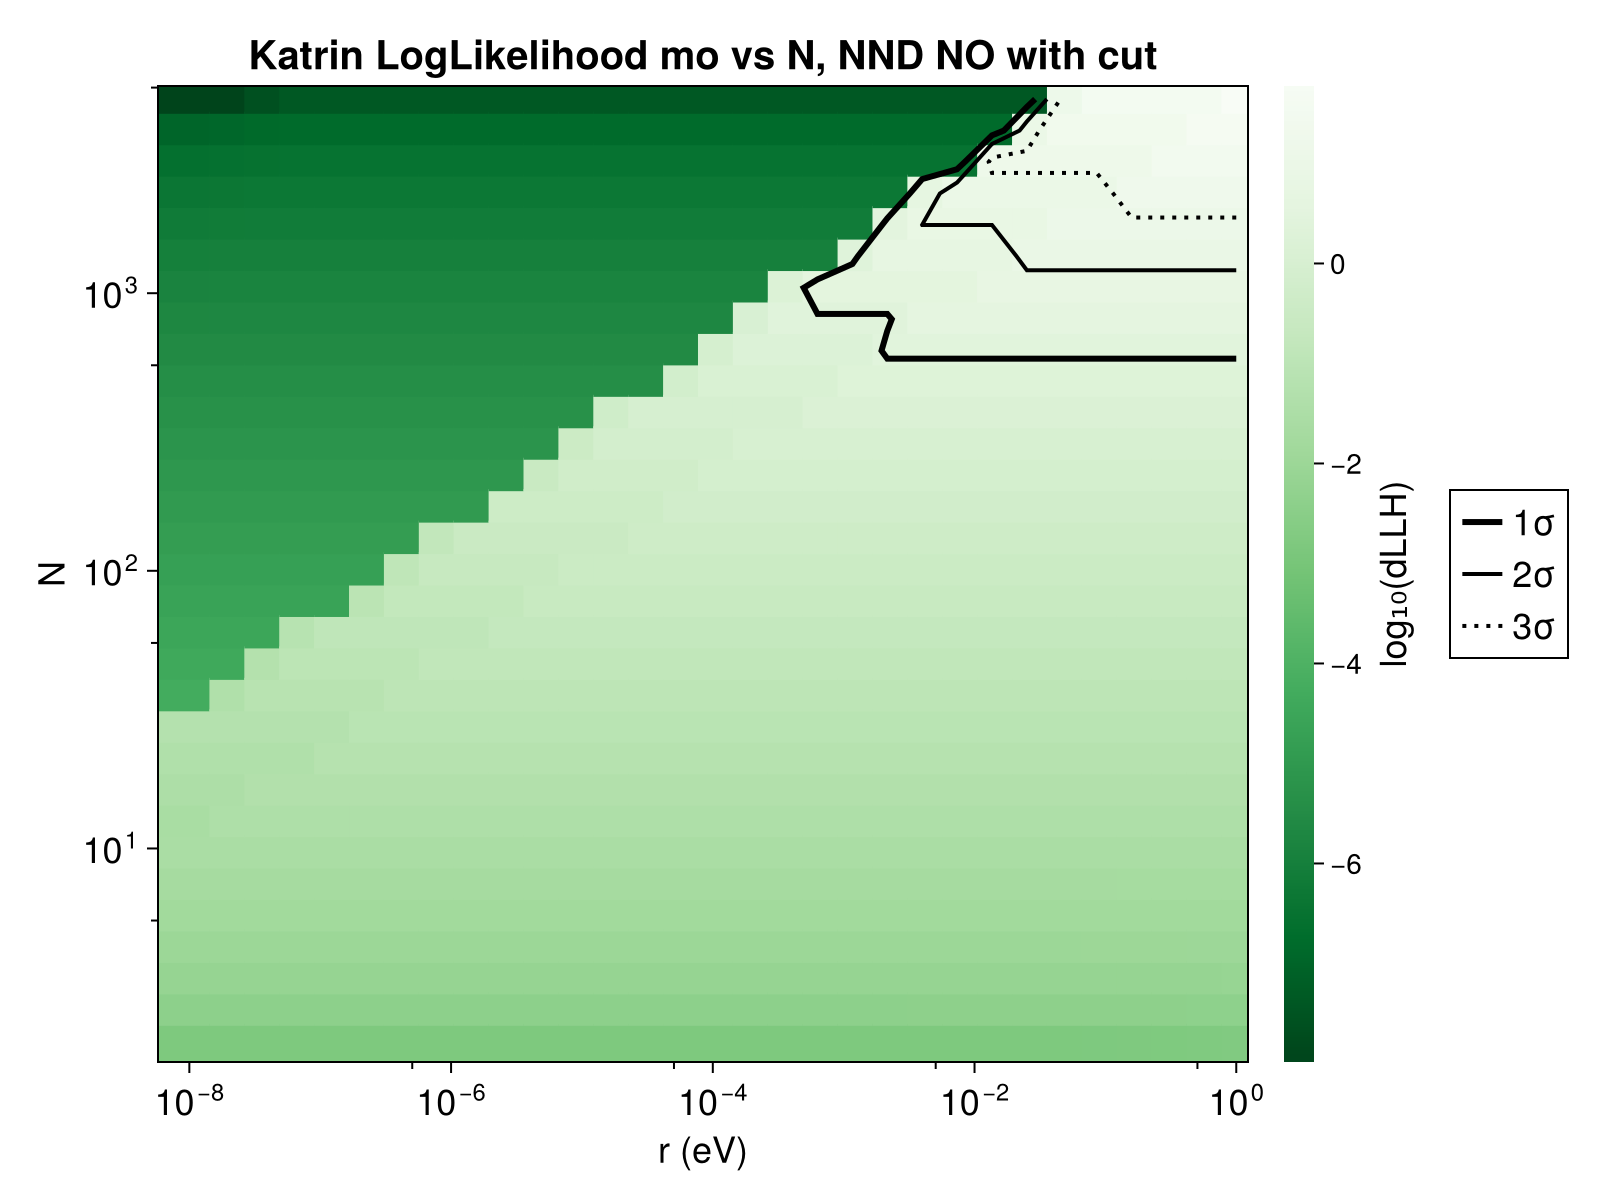

In [55]:

using CairoMakie

JLD2.@load "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/katrin5000_rN_NND_NO_lognew_m0=0.01.jld2" result

img = CairoMakie.plot(result; title="Katrin LogLikelihood mo vs N, NND NO with cut", log=3, mass=1, log_colormap=true )
display("image/png", img)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/katrin_m0N_NND_NO_cut.png", img)

Mass estimation


In [7]:
predicted_value =Newtrinos.katrin.get_neutrinomass(cfg)(params)

LoadError: UndefVarError: `cfg` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

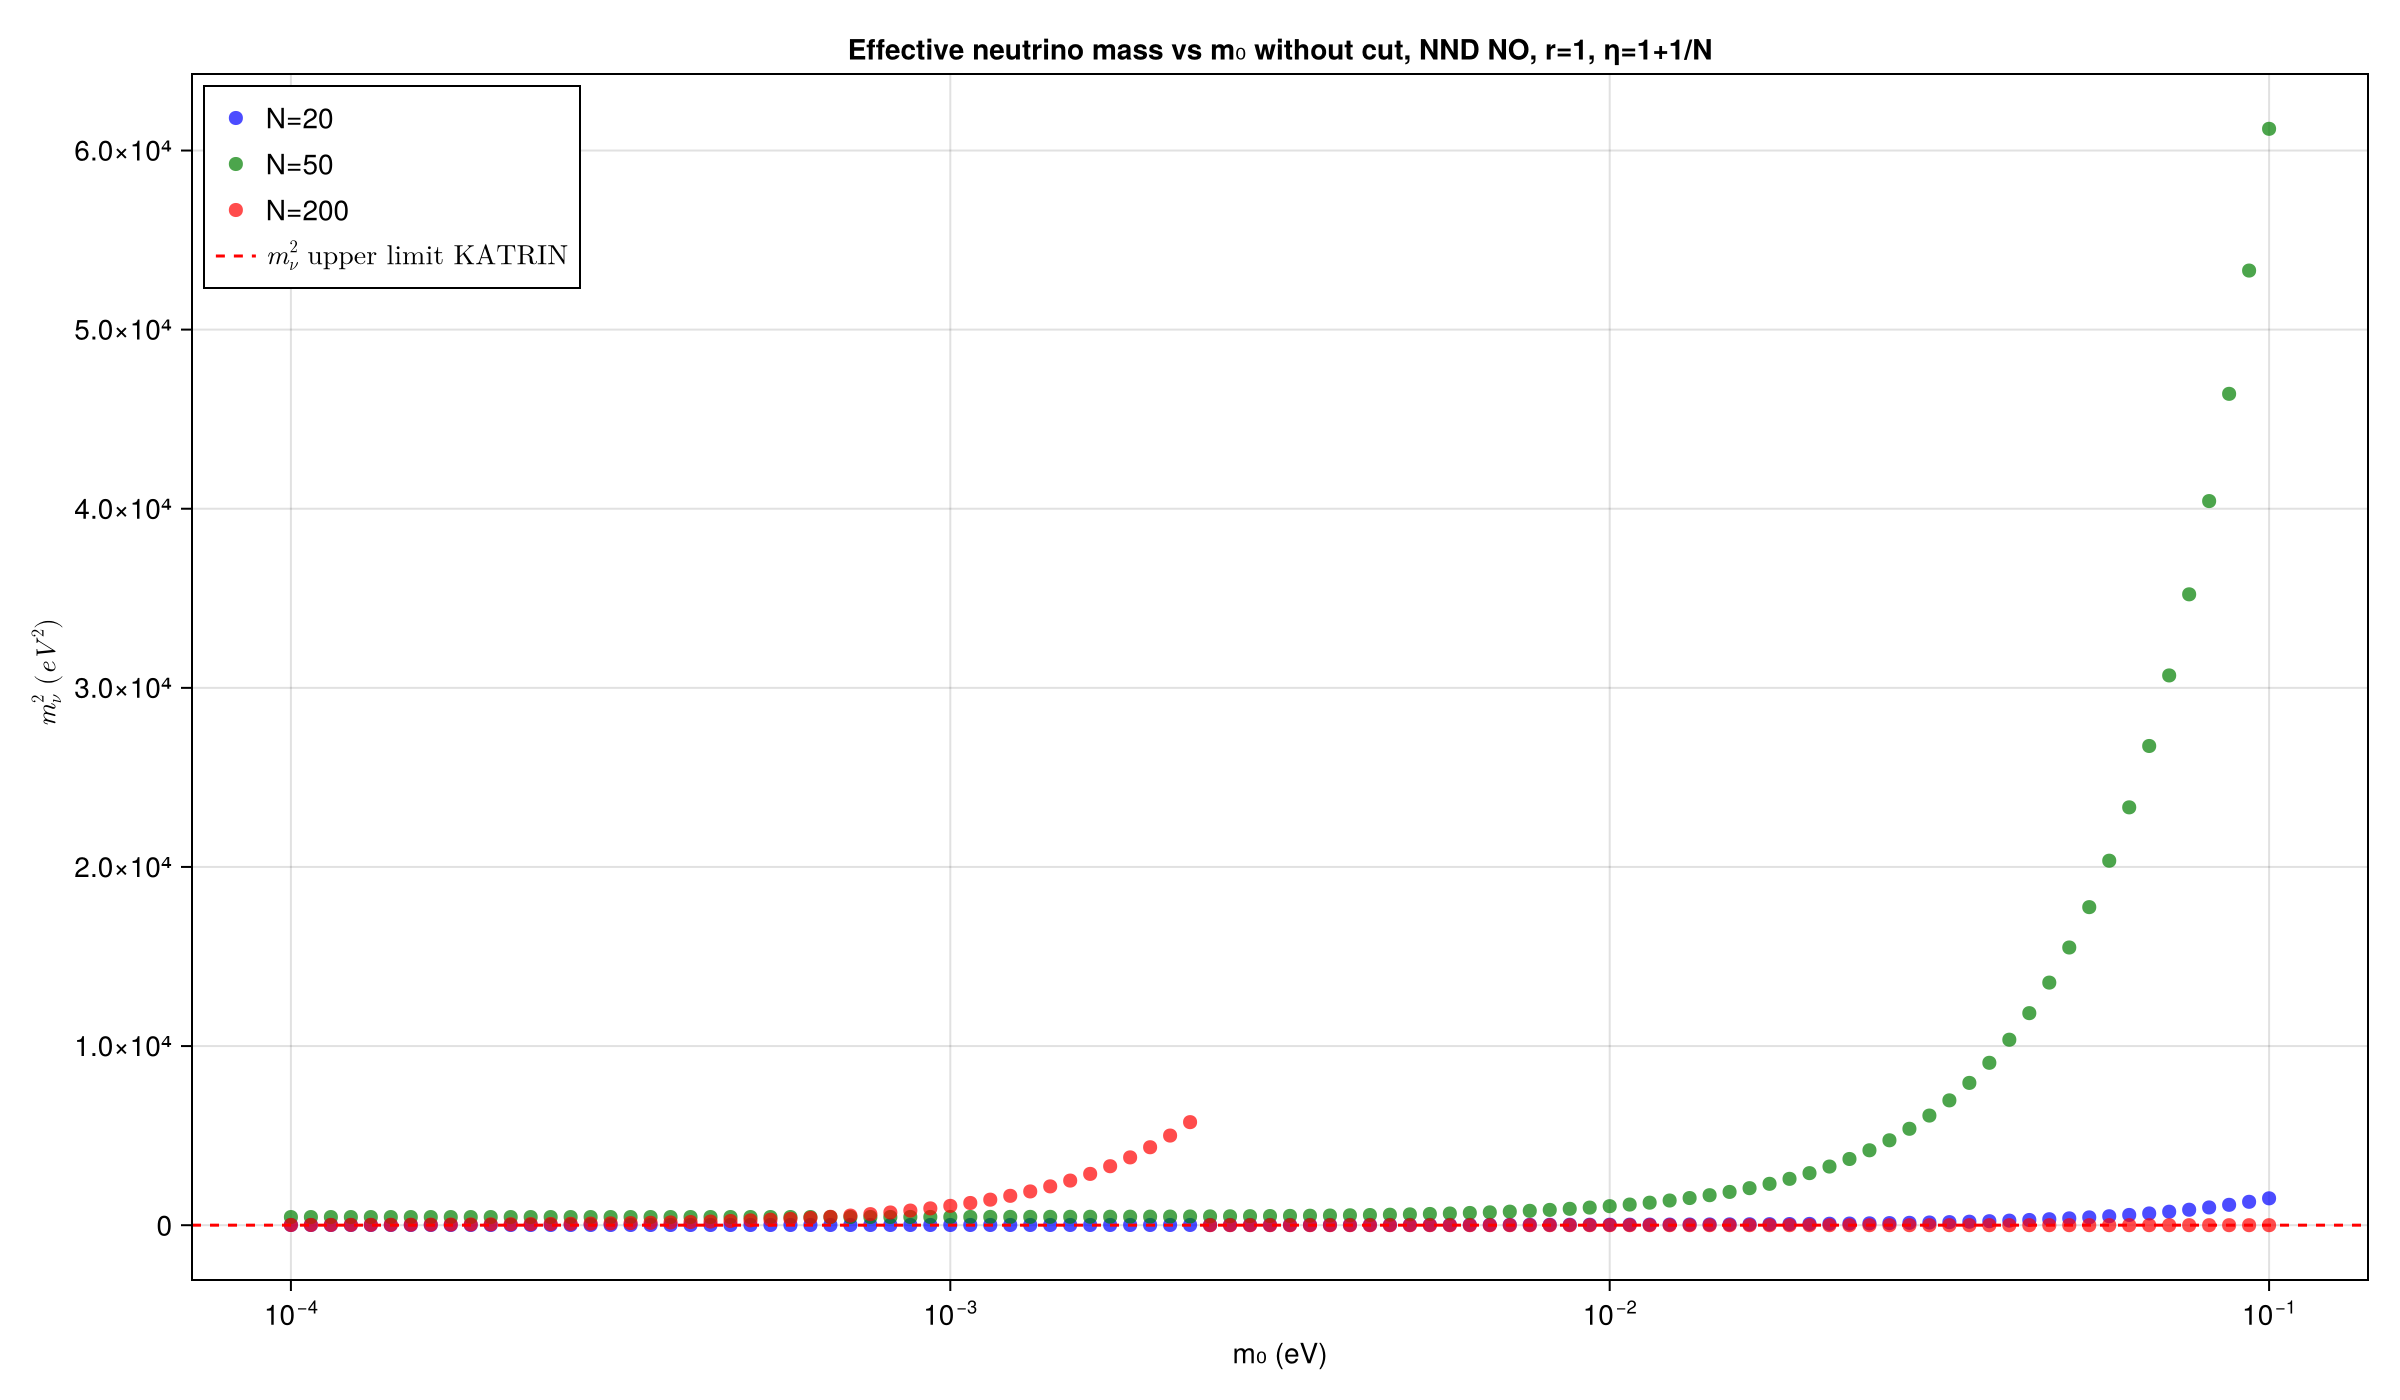

In [ ]:
using CairoMakie
using LaTeXStrings

m0_range=logrange(1e-4,0.1,100) #LinRange(0.01,1,20)#

m1=[]
m2=[]
m3=[]

N=par.N


for m0 in m0_range

    p1= merge(par, (m₀=m0,),(r=1,), (N=20,),)
    p2= merge(par, (m₀=m0,),(r=1,), (N=50,),)
    p3= merge(par,(m₀=m0,),(r=1,), (N=200,),)
    f1= Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)

    m1v=f1(p1)
    m2v=f1(p2)
    m3v=f1(p3)

    push!(m1, m1v)
    push!(m2, m2v)
    push!(m3, m3v)

end

fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xlabel="m₀ (eV)",
    ylabel= L" $m_\nu^2$ ($eV^2$)",
    title="Effective neutrino mass vs m₀ without cut, NND NO, r=1, η=1+1/N",
    xscale=log10)   
scatter!(ax, m0_range, m1, label="N=20", markersize=10, alpha=0.7, color=:blue)
scatter!(ax, m0_range, m2, label="N=50", markersize=10, alpha=0.7, color=:green)
scatter!(ax, m0_range, m3, label="N=200", markersize=10, alpha=0.7, color=:red)
hlines!(ax,0.01, linestyle=:dash, color=:red, label= L"$m_\nu^2$ upper limit KATRIN")
#vlines!(ax,1e-3, linestyle=:dash, color=:black, label= L"10^{-2}")
#vlines!(ax,1e-4, linestyle=:dash, color=:black, label= L"10^{-4}")
axislegend(ax, position=:lt)    
# Save and display
#save("/home/sofialon/Newtrinos.jl/plots_fix/katrin_try/nocut_m01.png", fig)
display("image/png",fig)

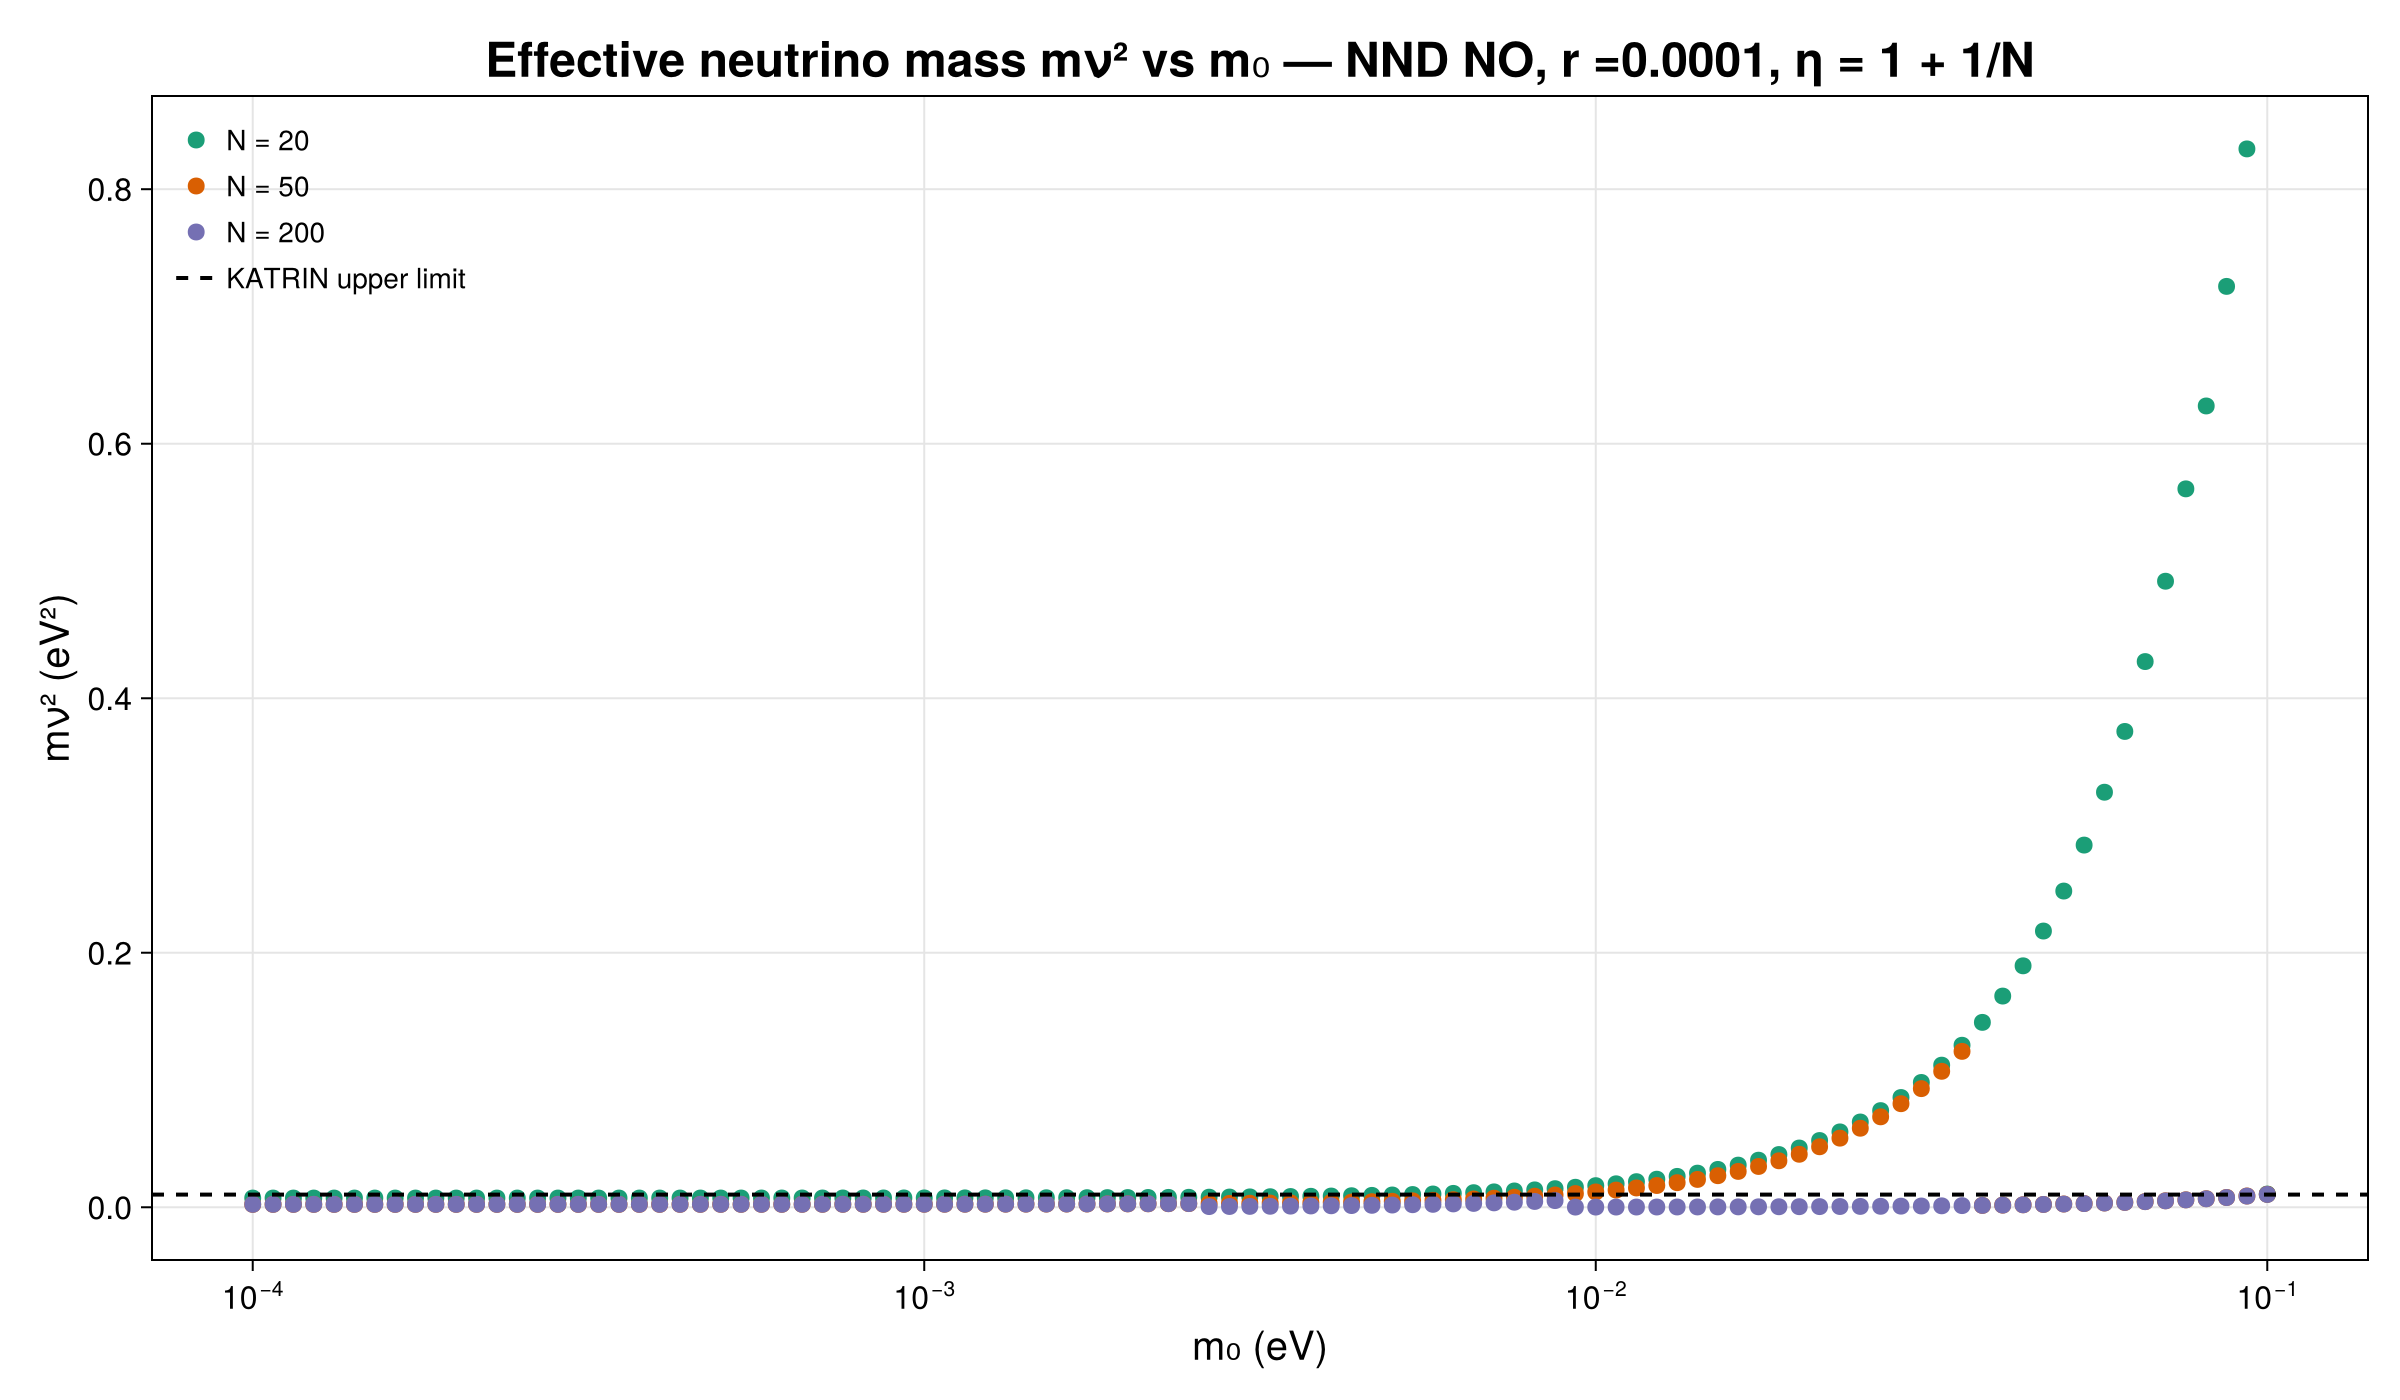

In [ ]:
using CairoMakie
using ColorSchemes

m0_range = logrange(1e-4, 0.1, 100)

m1 = Float64[]
m2 = Float64[]
m3 = Float64[]
r=1
for m0 in m0_range
    p1 = merge(par, (m₀ = m0,), (r = 1e-4,), (N = 20,))
    p2 = merge(par, (m₀ = m0,), (r = 1e-4,), (N = 50,))
    p3 = merge(par, (m₀ = m0,), (r = 1e-4,), (N = 200,))

    f = Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)
    r=p1.r
    push!(m1, f(p1))
    push!(m2, f(p2))
    push!(m3, f(p3))
end

# ===================== COLORS (Set2_9) =====================

cs = ColorSchemes.Dark2_8
c_N20  = cs[1]
c_N50  = cs[2]
c_N200 = cs[3]
c_lim  = :black

# ===================== FIGURE =====================

fig = Figure(size = (1200, 700))

ax = Axis(
    fig[1, 1],
    title = "Effective neutrino mass mν² vs m₀ — NND NO, r =$r, η = 1 + 1/N",
    xlabel = "m₀ (eV)",
    ylabel = "mν² (eV²)",
    xscale = log10,

    titlesize = 24,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 16,
    yticklabelsize = 16,

    xgridvisible = true,
    ygridvisible = true,
    xgridcolor = :gray90,
    ygridcolor = :gray90,
)

# ===================== DATA =====================

scatter!(
    ax, m0_range, m1;
    label = "N = 20",
    markersize = 12,
    color = c_N20,
    alpha =1.0
)

scatter!(
    ax, m0_range, m2;
    label = "N = 50",
    markersize = 12,
    color = c_N50,
    alpha = 1.0
)

scatter!(
    ax, m0_range, m3;
    label = "N = 200",
    markersize = 12,
    color = c_N200,
    alpha = 1.0
)

hlines!(
    ax, 0.01;
    linestyle = :dash,
    linewidth = 2,
    color = c_lim,
    label = "KATRIN upper limit"
)

# ===================== LEGEND =====================

axislegend(
    ax,
    position = :lt,
    framevisible = false,
    fontsize = 16
)

display("image/png", fig)

save("/home/sofialon/Newtrinos.jl/plots_fix/abs_phen/katrin_NND_NO_r($r).png", fig)


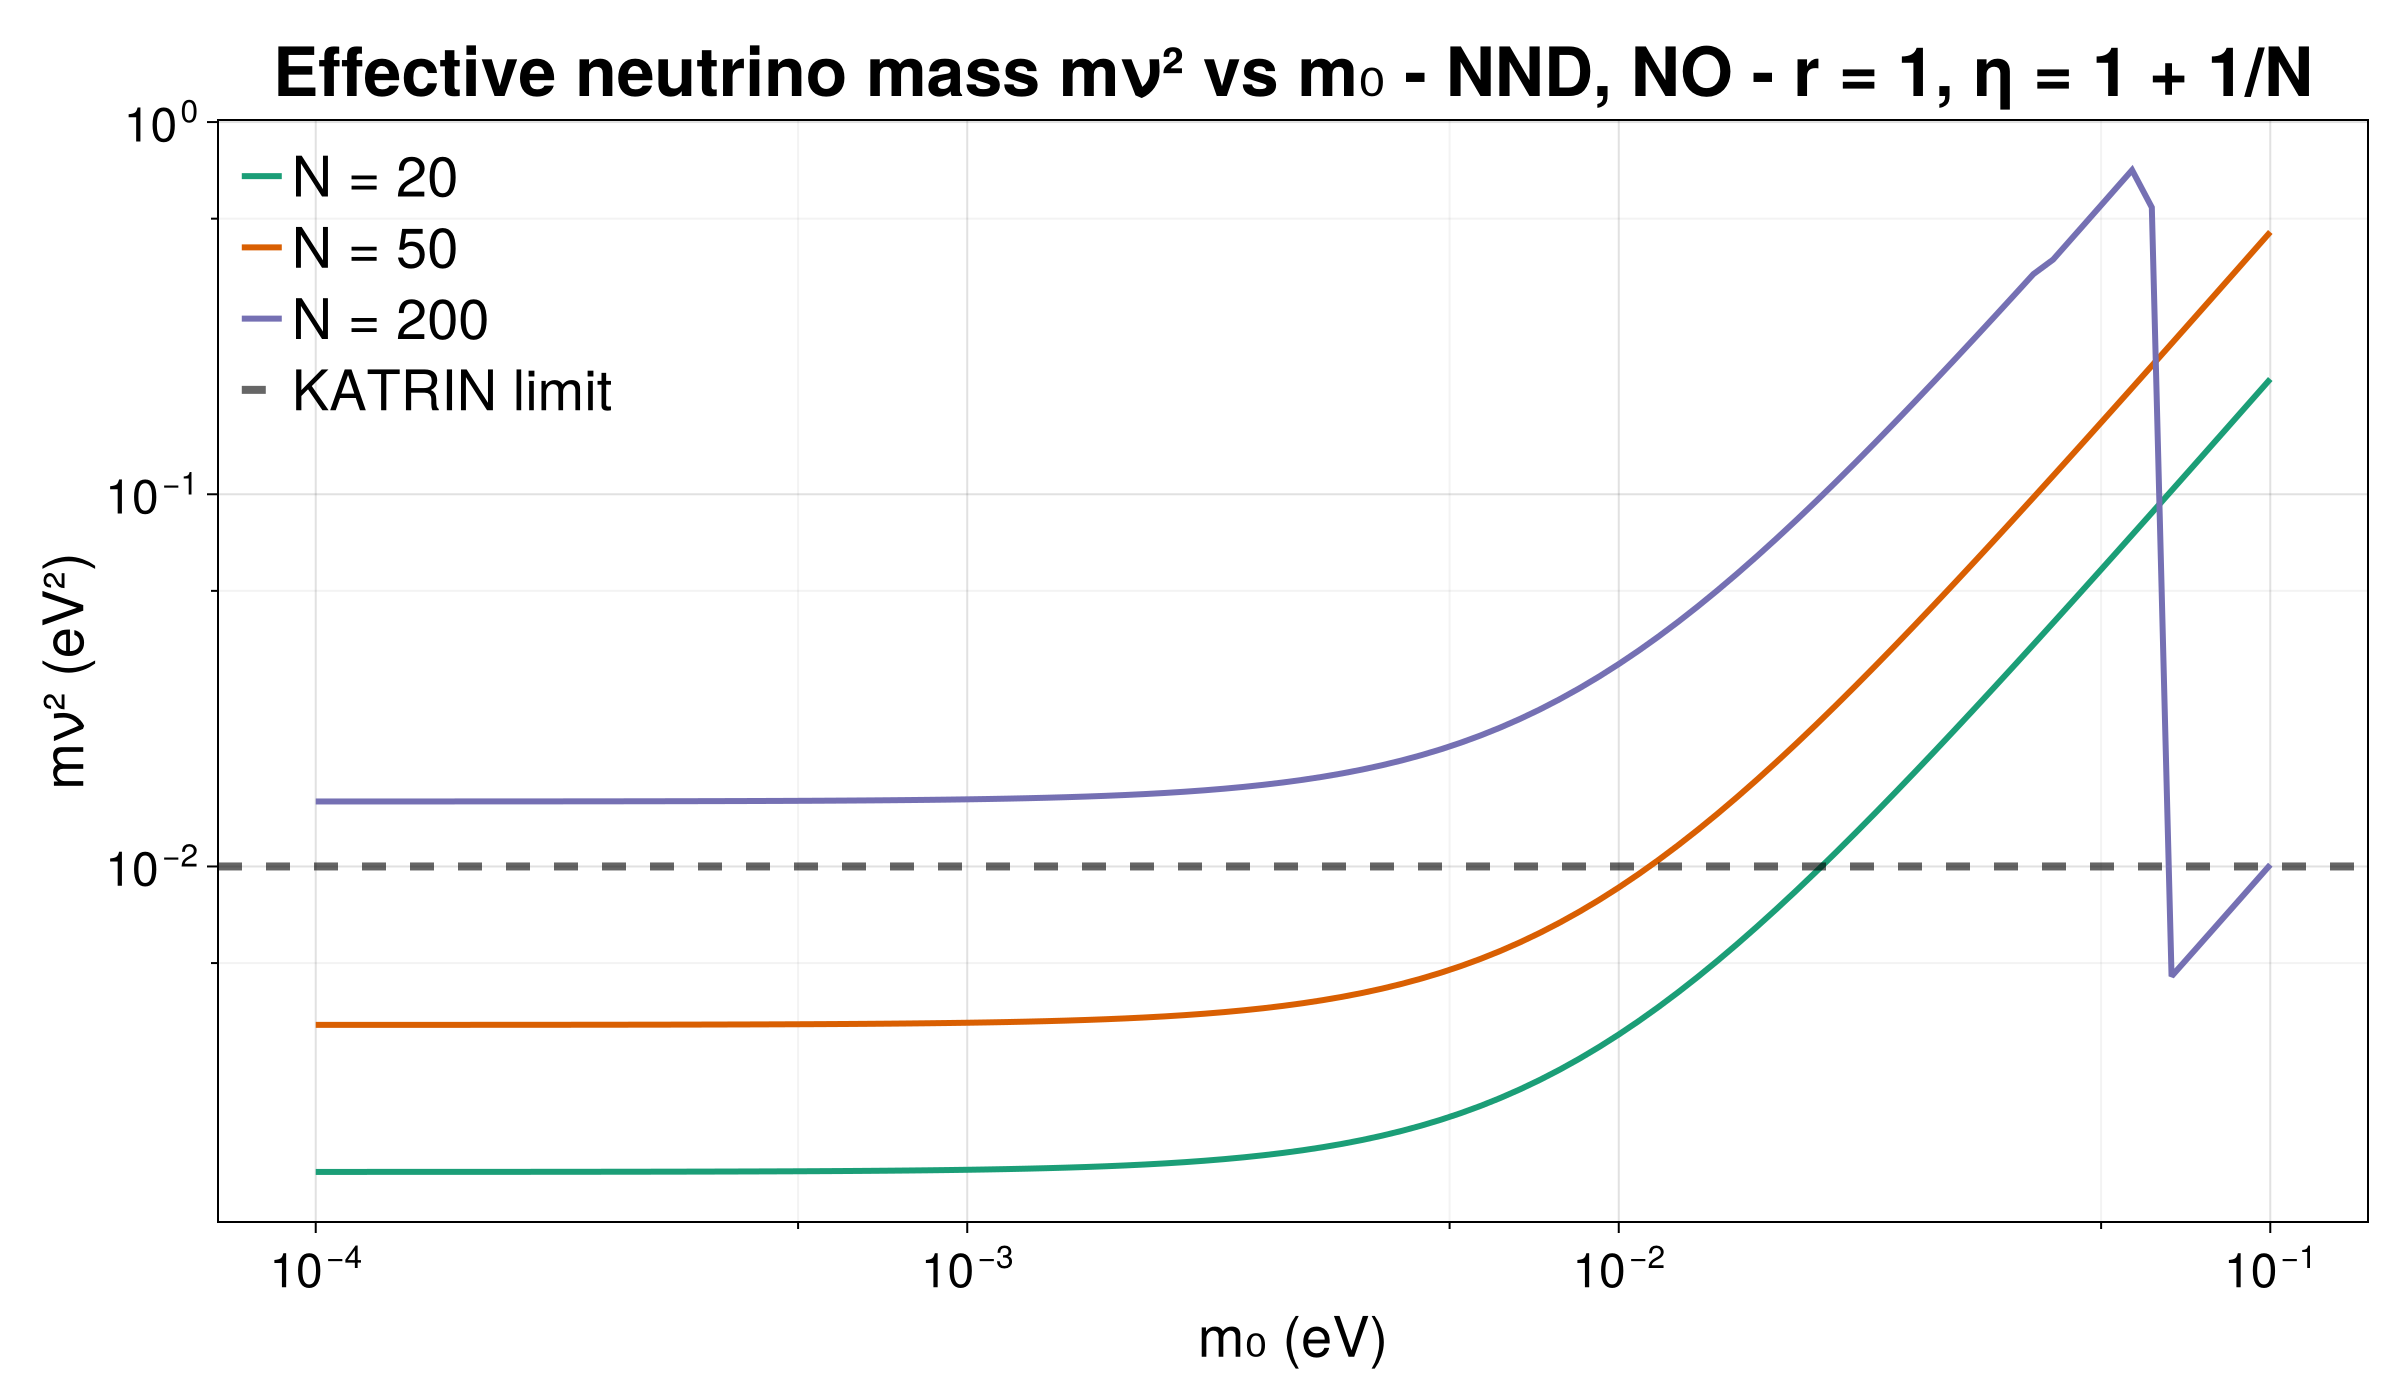

CairoMakie.Screen{SVG}


In [26]:
using CairoMakie
using ColorSchemes

# ===================== DATA =====================

m0_range = logrange(1e-4, 0.1, 100)

m1 = Float64[]
m2 = Float64[]
m3 = Float64[]

f = Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)

for m0 in m0_range
    for (N, container) in zip((20, 50, 200), (m1, m2, m3))
        p = merge(par, (m₀ = m0,), (r = 1e-4,), (N = N,))
        push!(container, f(p))
    end
end

r = 1

# ===================== COLORS =====================

cs = ColorSchemes.Dark2_8
c_N20  = cs[1]
c_N50  = cs[2]
c_N200 = cs[3]

# ===================== FIGURE =====================

fig = Figure(size = (1200, 700))

ax = Axis(
    fig[1, 1],
    title = "Effective neutrino mass mν² vs m₀ - NND, NO - r = $r, η = 1 + 1/N",
    xlabel = "m₀ (eV)",
    ylabel = "mν² (eV²)",

    xscale = log10,
    yscale = log10,
    xminorticksvisible = true,
    xminorgridvisible = true,
    yminorticksvisible = true,
    yminorgridvisible = true,
    titlesize = 34,
    xlabelsize = 28,
    ylabelsize = 28,
    xticklabelsize = 24,
    yticklabelsize = 24,
  
)

# ===================== PLOT =====================

for (data, color, label) in zip(
    (m1, m2, m3),
    (c_N20, c_N50, c_N200),
    ("N = 20", "N = 50", "N = 200")
)
    lines!(ax, m0_range, data;
        color = color,
        linewidth = 3,
        label = label,
    )
end

hlines!(ax, 0.01;
    linestyle = :dash,
    linewidth = 4,
    color = (:black, 0.6),
    label = "KATRIN limit"
)

axislegend(ax, position = :lt, framevisible = false, labelsize = 28)

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/katrin/katrin_NND_NO_N.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/katrin/katrin_NND_NO_N.svg", fig)

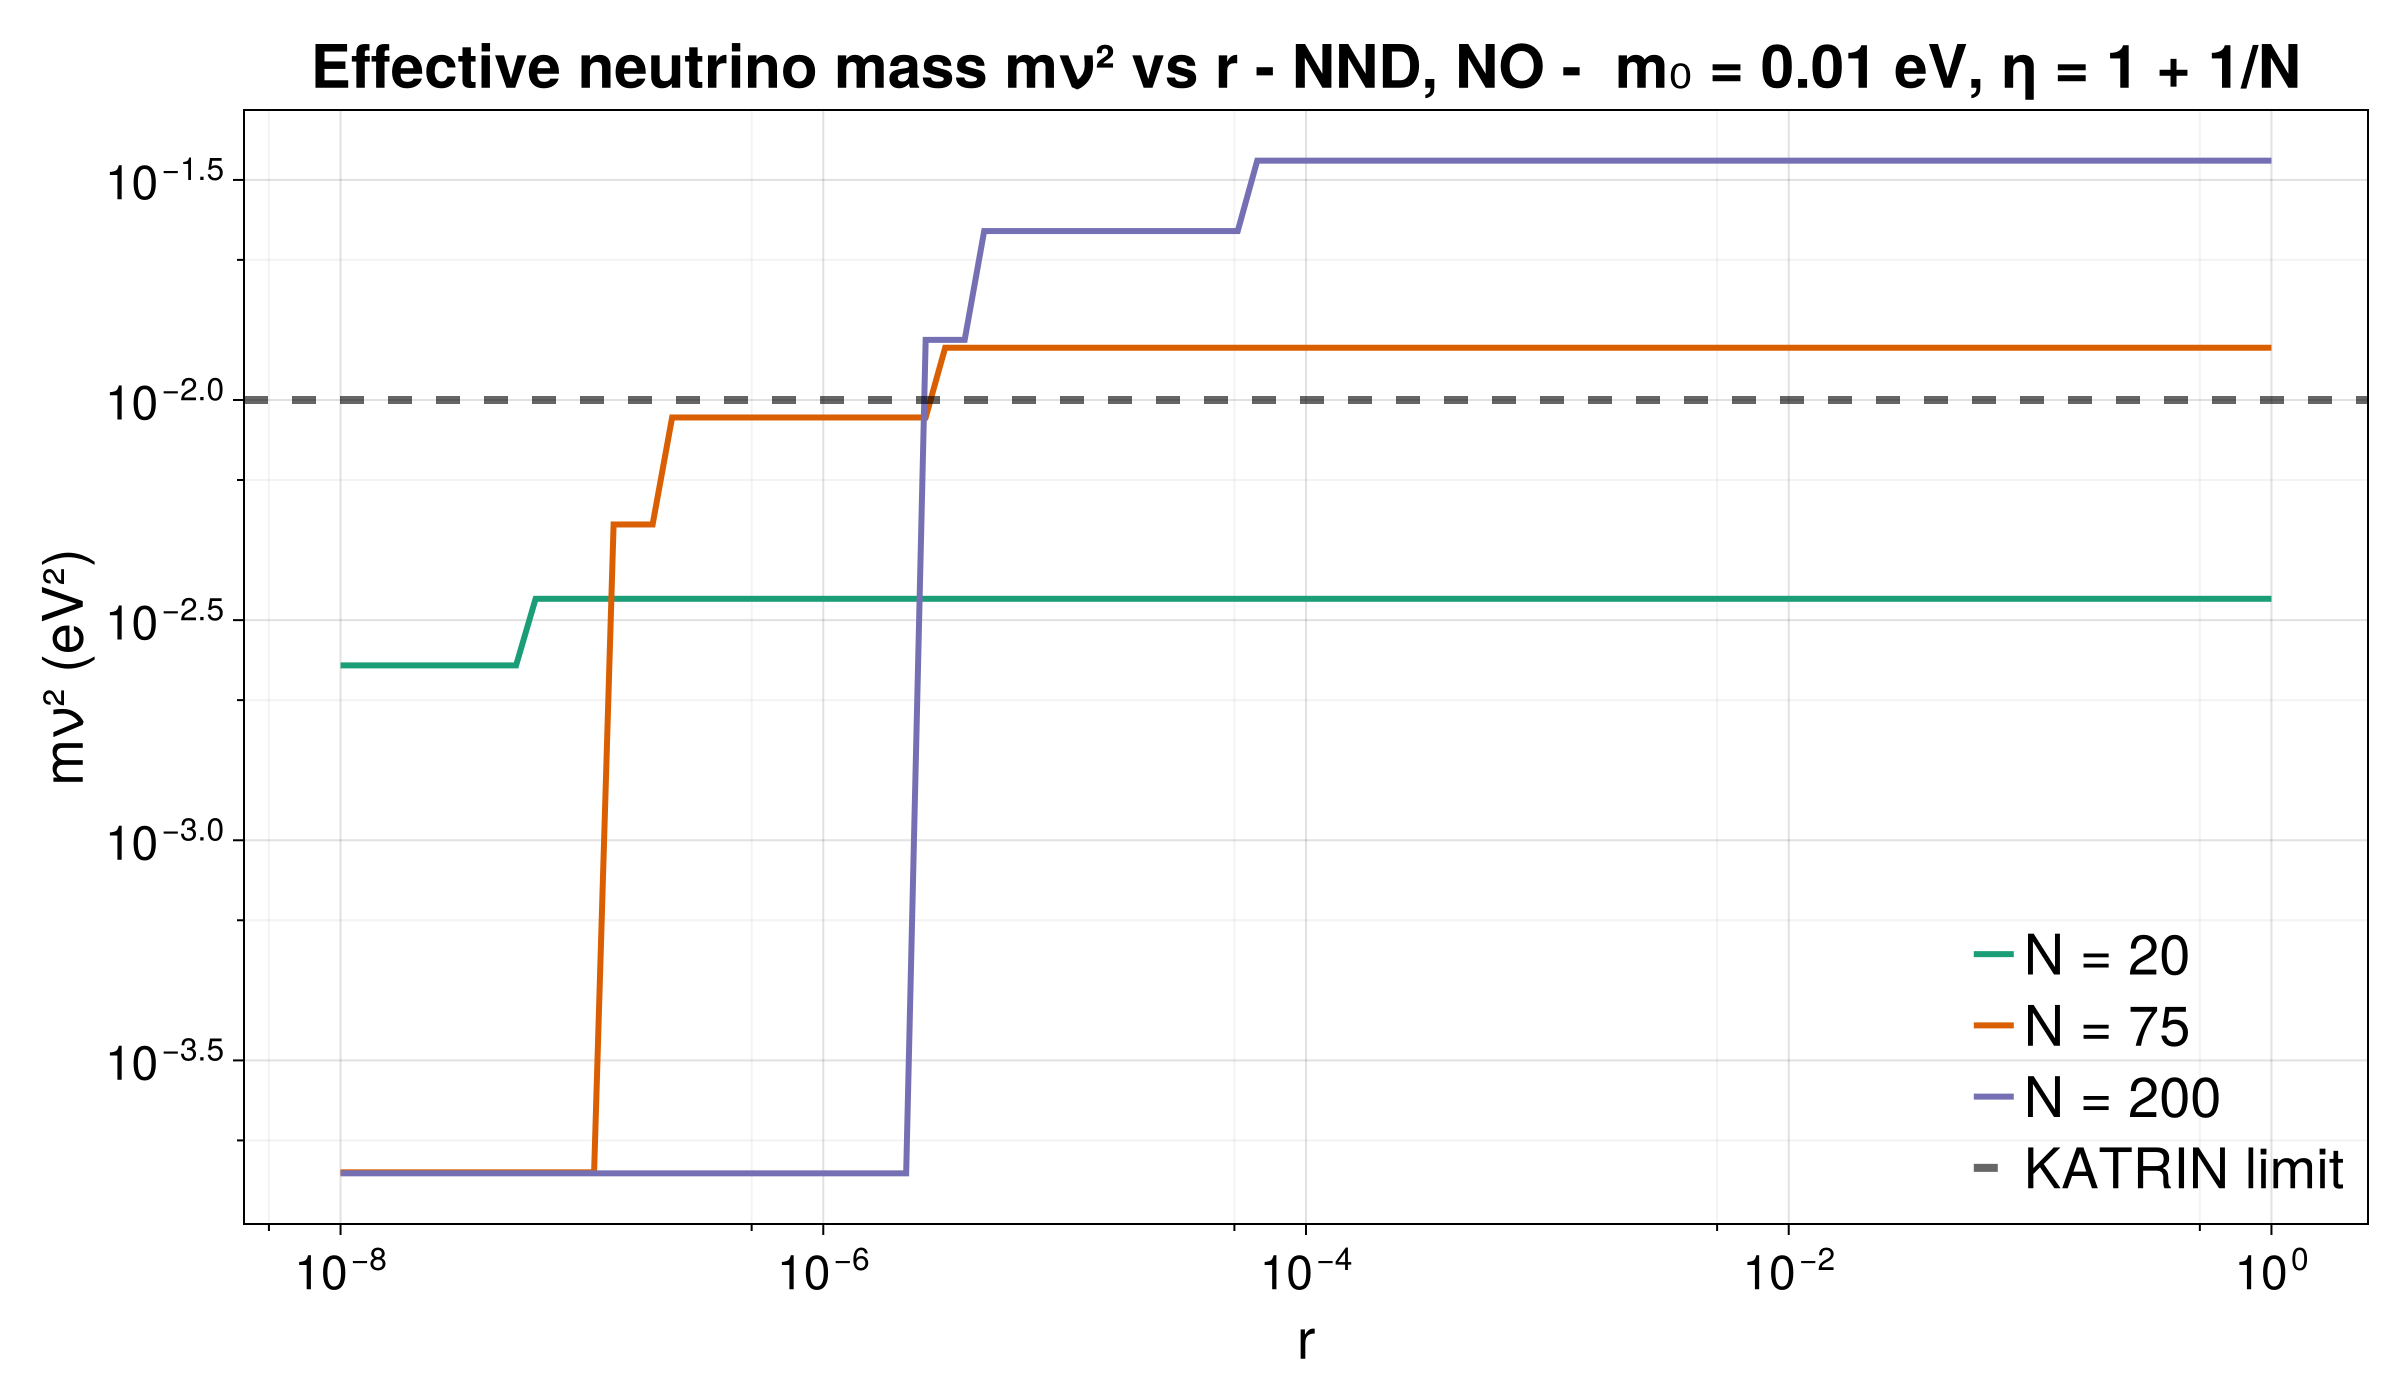

CairoMakie.Screen{SVG}


In [8]:
using CairoMakie
using ColorSchemes

# ===================== PARAMETERS =====================

r_range = logrange(1e-8, 1, 100)

m1 = Float64[]
m2 = Float64[]
m3 = Float64[]

par = merge(par, (m₀ = 0.01,))
m0 = par.m₀

# ===================== COMPUTATION =====================

f = Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)

for r in r_range
    for (N, container) in zip((20, 75, 200), (m1, m2, m3))
        p = merge(par, (r = r,), (N = N,))
        push!(container, f(p))
    end
end

# ===================== COLORS =====================

cs = ColorSchemes.Dark2_8
c_N20  = cs[1]
c_N75  = cs[2]
c_N200 = cs[3]

# ===================== FIGURE =====================

fig = Figure(size = (1200, 700))

ax = Axis(
    fig[1, 1],
    title = "Effective neutrino mass mν² vs r - NND, NO -  m₀ = $(m0) eV, η = 1 + 1/N",

    xlabel = "r",
    ylabel = "mν² (eV²)",

    xscale = log10,
    yscale = log10,

    xminorticksvisible = true,
    xminorgridvisible = true,
    yminorticksvisible = true,
    yminorgridvisible = true,
    titlesize = 30,
    xlabelsize = 28,
    ylabelsize = 28,
    xticklabelsize = 24,
    yticklabelsize = 24,
  
)

# ===================== PLOT =====================

for (data, color, label) in zip(
    (m1, m2, m3),
    (c_N20, c_N75, c_N200),
    ("N = 20", "N = 75", "N = 200")
)
    lines!(ax, r_range, data;
        color = color,
        linewidth = 3,
        label = label,
    )
end

hlines!(ax, 0.01;
    linestyle = :dash,
    linewidth = 4,
    color = (:black, 0.6),
    label = "KATRIN limit"
)

axislegend(ax, position = :rb, framevisible = false, labelsize = 28)

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/katrin/katrin_NND_NO_r.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/katrin/katrin_NND_NO_r.svg", fig)

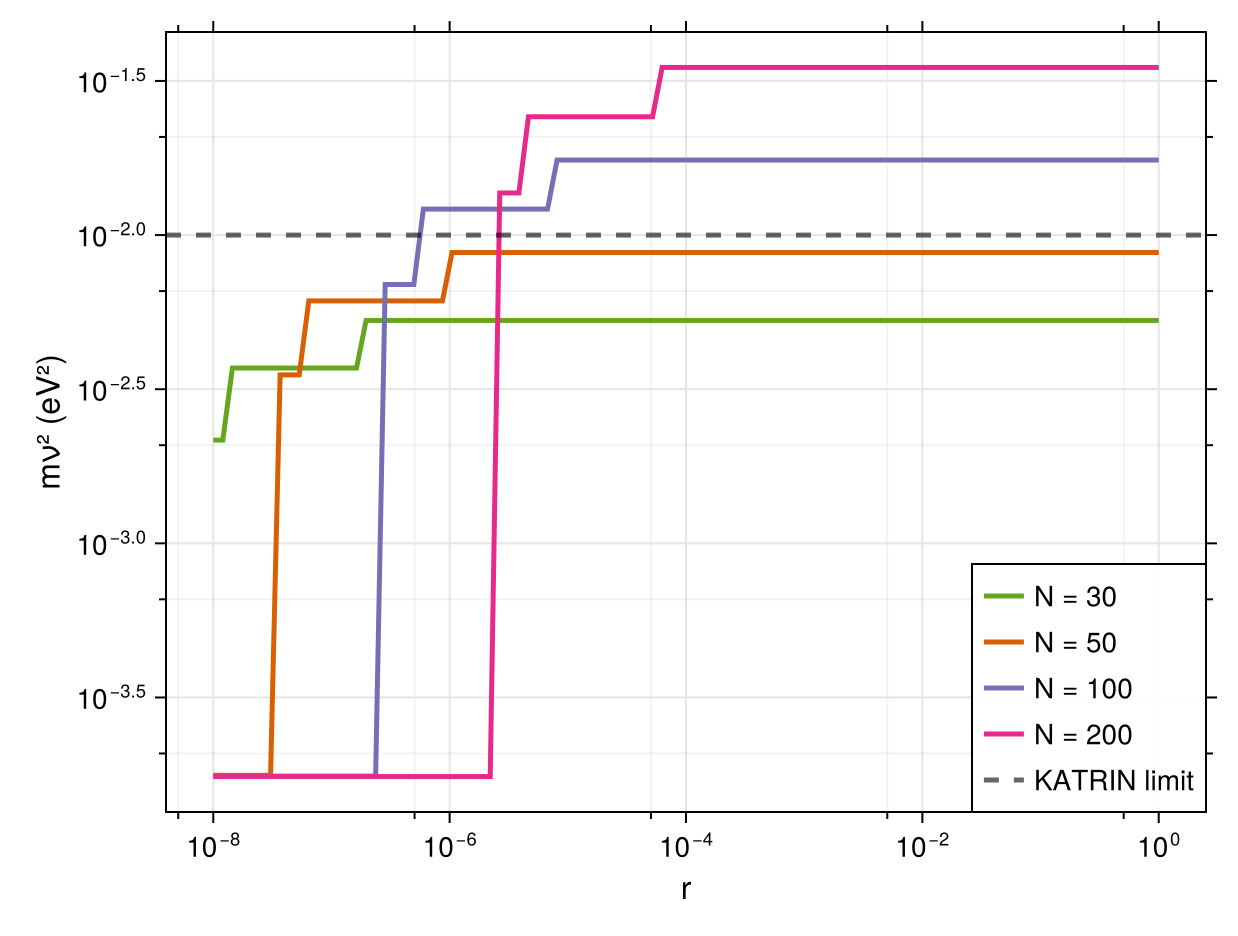

CairoMakie.Screen{SVG}


In [17]:
using CairoMakie
using ColorSchemes

# ===================== PARAMETERS =====================

r_range = logrange(1e-8, 1, 100)

m1 = Float64[]
m2 = Float64[]
m3 = Float64[]
m4 = Float64[]

par = merge(par, (m₀ = 0.01,))
m0 = par.m₀

# ===================== COMPUTATION =====================

f = Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)

for r in r_range
    for (N, container) in zip((30, 50, 100, 200), (m1, m2, m3, m4))
        p = merge(par, (r = r,), (N = N,))
        push!(container, f(p))
    end
end

# ===================== COLORS (ORIGINAL ASSIGNMENTS PRESERVED) =====================

cs = ColorSchemes.Dark2_8
c_N30  = cs[5]   # N = 30
c_N50  = cs[2]   # N = 50
c_N100 = cs[3]   # N = 100
c_N200 = cs[4]   # N = 200

# ===================== FIGURE - PRD STYLE =====================

fig = Figure(size=(8.6*72, 6.5*72), font="CMU Serif")  # PRD single column width

ax = Axis(
    fig[1, 1],
    #title = "Effective neutrino mass mν² vs r - NND, NO - m₀ = $(m0) eV, η = 1 + 1/N",
    xlabel = "r",
    ylabel = "mν² (eV²)",
    xscale = log10,
    yscale = log10,
    xminorticksvisible = true,
    xminorgridvisible = true,
    yminorticksvisible = true,
    yminorgridvisible = true,
    titlesize = 18,
    xlabelsize = 16,
    ylabelsize = 16,
    xticklabelsize = 14,
    yticklabelsize = 14,
    xgridvisible = true,
    ygridvisible = true,
    xgridcolor = :gray90,
    ygridcolor = :gray90,
    xticksmirrored = true,
    yticksmirrored = true
)

# ===================== PLOT =====================

for (data, color, label) in zip(
    (m1, m2, m3, m4),
    (c_N30, c_N50, c_N100, c_N200),
    ("N = 30", "N = 50", "N = 100", "N = 200")
)
    lines!(ax, r_range, data;
        color = color,
        linewidth = 2.5,
        label = label,
    )
end

hlines!(ax, 0.01;
    linestyle = :dash,
    linewidth = 2.5,
    color = (:black, 0.6),
    label = "KATRIN limit"
)

# ===================== LEGEND WITH BOX =====================

# Create legend elements
legend_elements = [
    LineElement(color = c_N30, linewidth = 2.5, linestyle = :solid),
    LineElement(color = c_N50, linewidth = 2.5, linestyle = :solid),
    LineElement(color = c_N100, linewidth = 2.5, linestyle = :solid),
    LineElement(color = c_N200, linewidth = 2.5, linestyle = :solid),
    LineElement(color = (:black, 0.6), linewidth = 2.5, linestyle = :dash)
]

legend_labels = ["N = 30", "N = 50", "N = 100", "N = 200", "KATRIN limit"]

Legend(
    fig[1,1],
    legend_elements,
    legend_labels;
    tellwidth = false,
    tellheight = false,
    halign = :right,
    valign = :bottom,
    labelsize = 14,
    framevisible = true,
    backgroundcolor = (:white, 0.95),
    strokecolor = :black,
    strokewidth = 0.5,
    title = "N values",
    titlefont = :bold,
    titlesize = 16
)

# Display and save
display(fig)

save("/home/sofialon/Newtrinos.jl/scan_plot_paper/katrin_NND_NO_r.png", fig)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/katrin_NND_NO_r.svg", fig)

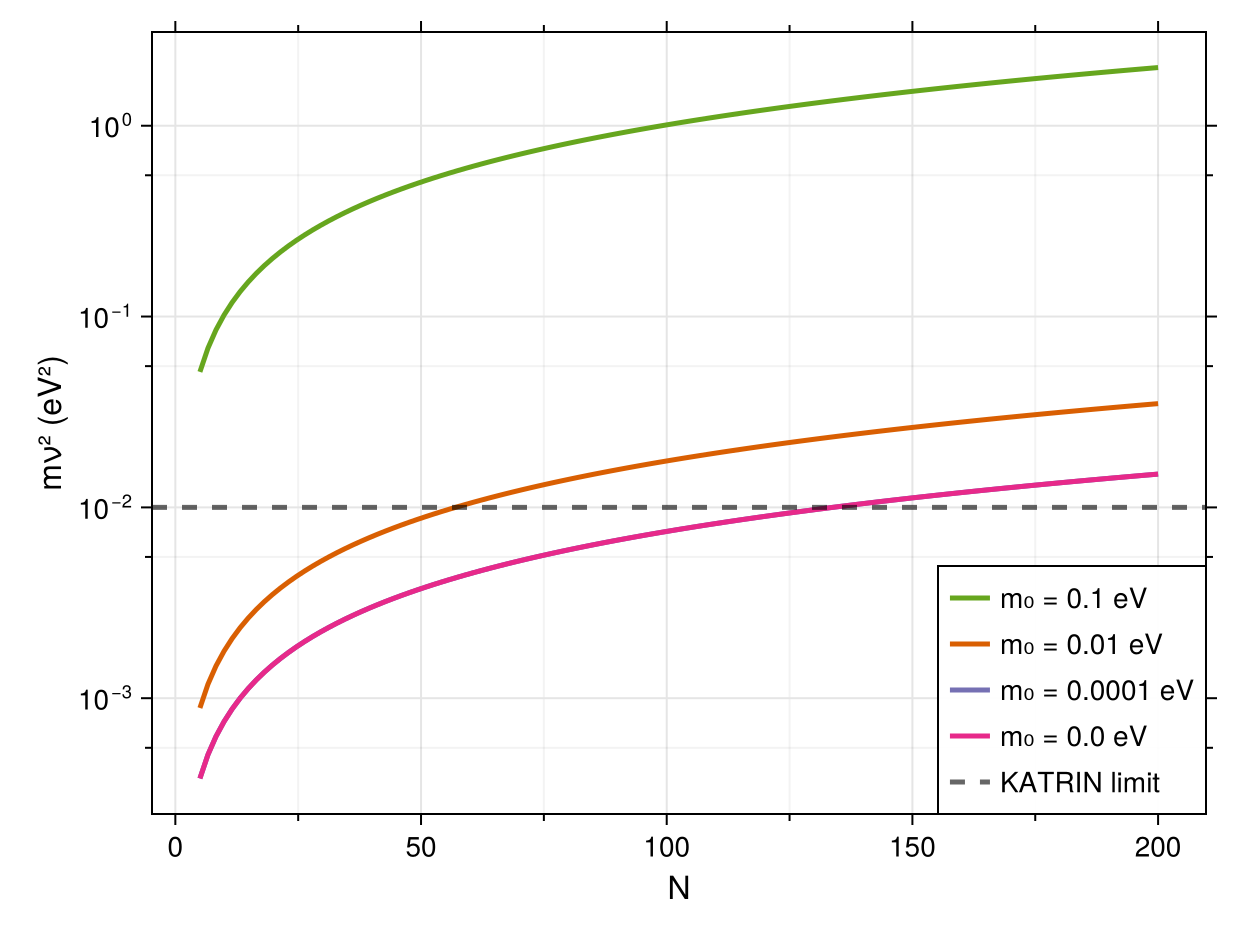

CairoMakie.Screen{SVG}


In [21]:
using CairoMakie
using ColorSchemes

# ===================== PARAMETERS =====================

N_range  = range(5, 200, length = 120)
m0_values = [0.1, 0.01, 1e-4, 0.0]
r = 1

mass_by_m0 = Dict(m0 => Float64[] for m0 in m0_values)

f = Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)

# ===================== COMPUTATION =====================

for N in N_range
    for m0 in m0_values
        par_p = merge(par, (m₀ = m0, r = r, N = N))
        push!(mass_by_m0[m0], f(par_p))
    end
end

# ===================== COLORS (ORIGINAL ASSIGNMENTS PRESERVED) =====================

cs = ColorSchemes.Dark2_8
colors = Dict(
    0.1    => cs[5],
    0.01   => cs[2],
    1e-4  => cs[3],
    0.0   => cs[4]
)

c_lim = :black

# ===================== FIGURE - PRD STYLE =====================

fig = Figure(size=(8.6*72, 6.5*72), font="CMU Serif") # PRD single column width

ax = Axis(
    fig[1, 1],
    #title = "Effective neutrino mass mν² vs N - NND, NO - r=1, η = 1 + 1/N",
    xlabel = "N",
    ylabel = "mν² (eV²)",
    #xscale = log10,
    yscale = log10,
    xminorticksvisible = true,
    xminorgridvisible = true,
    yminorticksvisible = true,
    yminorgridvisible = true,
    titlesize = 18,
    xlabelsize = 16,
    ylabelsize = 16,
    xticklabelsize = 14,
    yticklabelsize = 14,
    xgridvisible = true,
    ygridvisible = true,
    xgridcolor = :gray90,
    ygridcolor = :gray90,
    xticksmirrored = true,
    yticksmirrored = true
)

# ===================== PLOTS =====================

for m0 in m0_values
    lines!(
        ax,
        N_range,
        mass_by_m0[m0];
        label = "m₀ = $(m0) eV",
        linewidth = 2.5,
        color = colors[m0]
    )
end

hlines!(ax, 0.01;
    linestyle = :dash,
    linewidth = 2.5,
    color = (:black, 0.6),
    label = "KATRIN limit"
)

# ===================== LEGEND WITH BOX =====================

# Create legend elements
legend_elements = []
legend_labels = []

for m0 in m0_values
    push!(legend_elements, LineElement(color = colors[m0], linewidth = 2.5, linestyle = :solid))
    push!(legend_labels, "m₀ = $(m0) eV")
end

push!(legend_elements, LineElement(color = (:black, 0.6), linewidth = 2.5, linestyle = :dash))
push!(legend_labels, "KATRIN limit")

Legend(
    fig[1,1],
    legend_elements,
    legend_labels;
    tellwidth = false,
    tellheight = false,
    halign = :right,
    valign = :bottom,
    labelsize = 14,
    framevisible = true,
    backgroundcolor = (:white, 0.95),
    strokecolor = :black,
    strokewidth = 0.5,
    title = "m₀ values",
    titlefont = :bold,
    titlesize = 16
)

# Display and save
display(fig)

save("/home/sofialon/Newtrinos.jl/scan_plot_paper/katrin_NND_NO_m0.png", fig)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/katrin_NND_NO_m0.svg", fig)

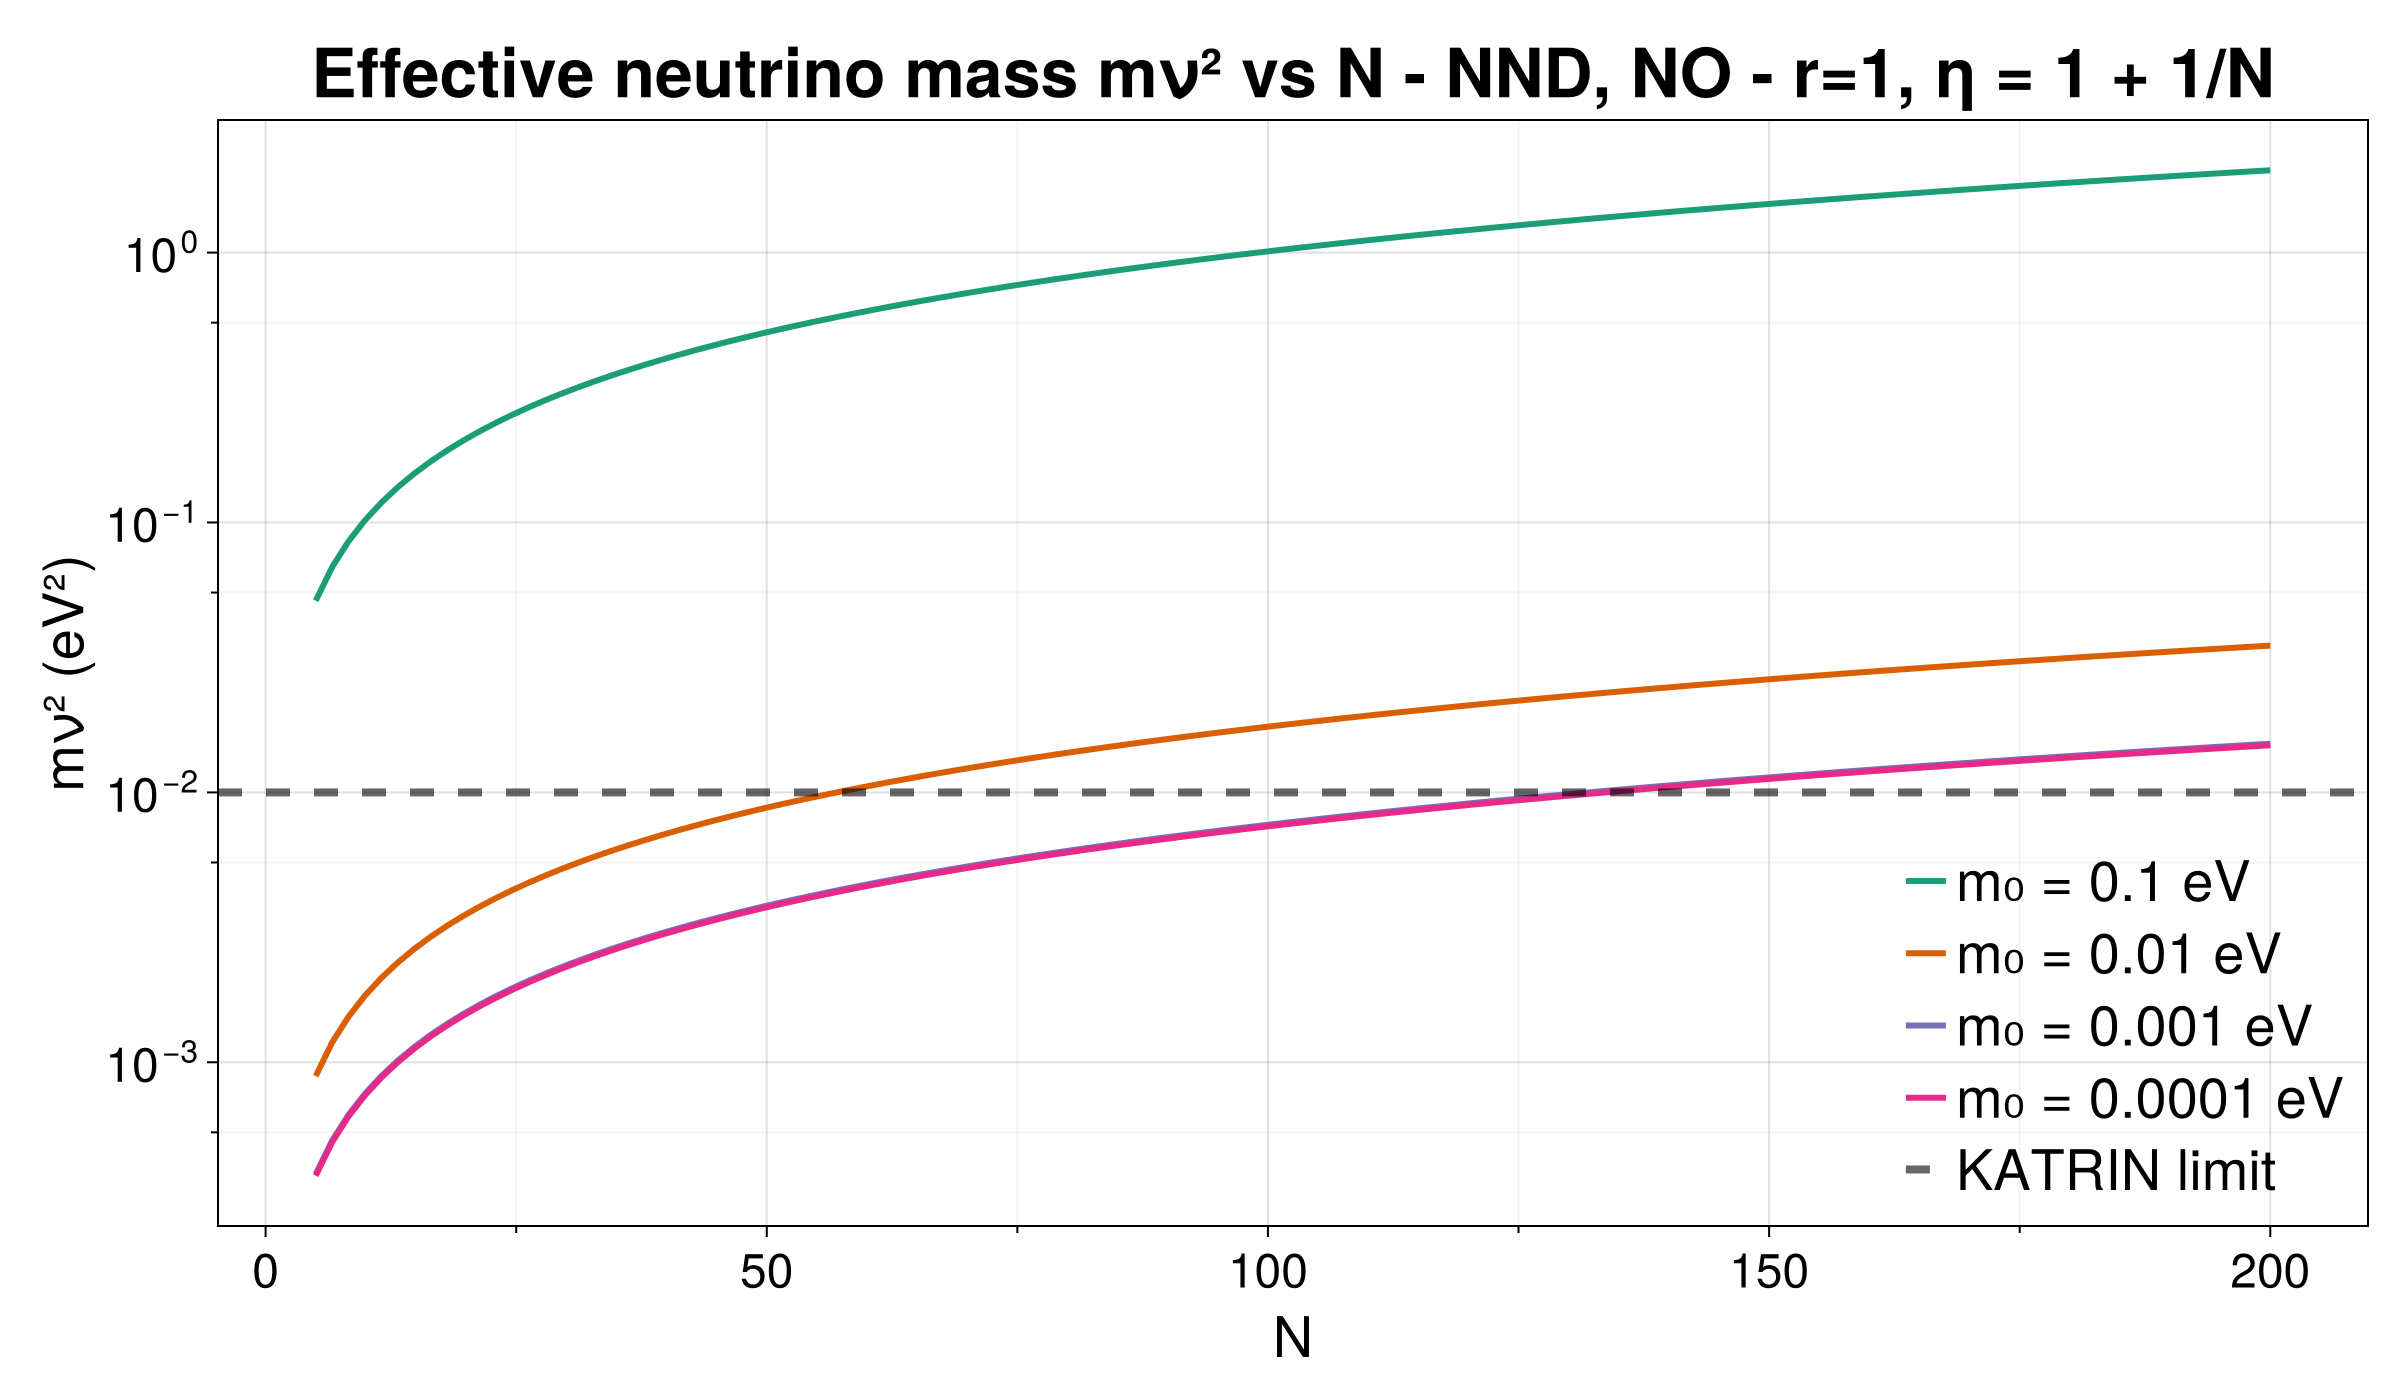

CairoMakie.Screen{SVG}


In [9]:
using CairoMakie
using ColorSchemes

# ===================== PARAMETERS =====================

N_range  = range(5, 200, length = 120)
m0_values = [0.1, 0.01, 1e-3, 1e-4]
r = 1

mass_by_m0 = Dict(m0 => Float64[] for m0 in m0_values)

f = Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)

# ===================== COMPUTATION =====================

for N in N_range
    for m0 in m0_values
        par_p = merge(par, (m₀ = m0, r = r, N = N))
        push!(mass_by_m0[m0], f(par_p))
    end
end

# ===================== COLORS =====================

cs = ColorSchemes.Dark2_8
colors = Dict(
    0.1    => cs[1],
    0.01   => cs[2],
    1e-3  => cs[3],
    1e-4 => cs[4]
)

c_lim = :black

# ===================== FIGURE =====================

fig = Figure(size = (1200, 700))

ax = Axis(
    fig[1, 1],
     title = "Effective neutrino mass mν² vs N - NND, NO - r=1, η = 1 + 1/N",

    xlabel = "N",
    ylabel = "mν² (eV²)",

    #xscale = log10,
    yscale = log10,

    xminorticksvisible = true,
    xminorgridvisible = true,
    yminorticksvisible = true,
    yminorgridvisible = true,
    titlesize = 34,
    xlabelsize = 28,
    ylabelsize = 28,
    xticklabelsize = 24,
    yticklabelsize = 24,
)

# ===================== PLOTS =====================

for m0 in m0_values
    lines!(
        ax,
        N_range,
        mass_by_m0[m0];
        label = "m₀ = $(m0) eV",
        linewidth = 3,
        color = colors[m0]
    )
end

hlines!(ax, 0.01;
    linestyle = :dash,
    linewidth = 4,
    color = (:black, 0.6),
    label = "KATRIN limit"

)
# ===================== LEGEND =====================

axislegend(ax, position = :rb, framevisible = false, labelsize = 28)

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/katrin/katrin_NND_NO_m0.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/katrin/katrin_NND_NO_m0.svg", fig)


Mixing angles

In [5]:
par_p= merge(par, (m₀=0.01, r=1, N=100))   

mass_e, mass_m, mass_t, angles_e, angles_m, angles_t = Newtrinos.katrin.mixing_angles( par_p, osc_cfg.flavour)

angles_e=angles_e[2:end-1]
angles_m=angles_m[2:end-1]
angles_t=angles_t[2:end-1]

mass_e=mass_e[2:end-1]
mass_m=mass_m[2:end-1]
mass_t=mass_t[2:end-1]


cont_e=mass_e.*(angles_e).^2
cont_m=mass_m.*(angles_m).^2
cont_t=mass_t.*(angles_t).^2






98-element Vector{Float64}:
 1.0666954677876165e-8
 7.026519031302268e-9
 5.834326468372739e-9
 5.194812577189635e-9
 4.773063709405127e-9
 4.462198438331968e-9
 4.216971946879411e-9
 4.014651506040103e-9
 3.842406747000633e-9
 3.692358684439293e-9
 3.5593490894222536e-9
 3.4398273258828297e-9
 3.331248967149863e-9
 ⋮
 6.661301535144969e-10
 6.388268394796221e-10
 6.106619245908391e-10
 5.814613922963664e-10
 5.509991194287302e-10
 5.189716486580729e-10
 4.849549447317828e-10
 4.4832450407882817e-10
 4.080923514069328e-10
 3.625243145140918e-10
 3.0802426233702945e-10
 2.3430464030592696e-10

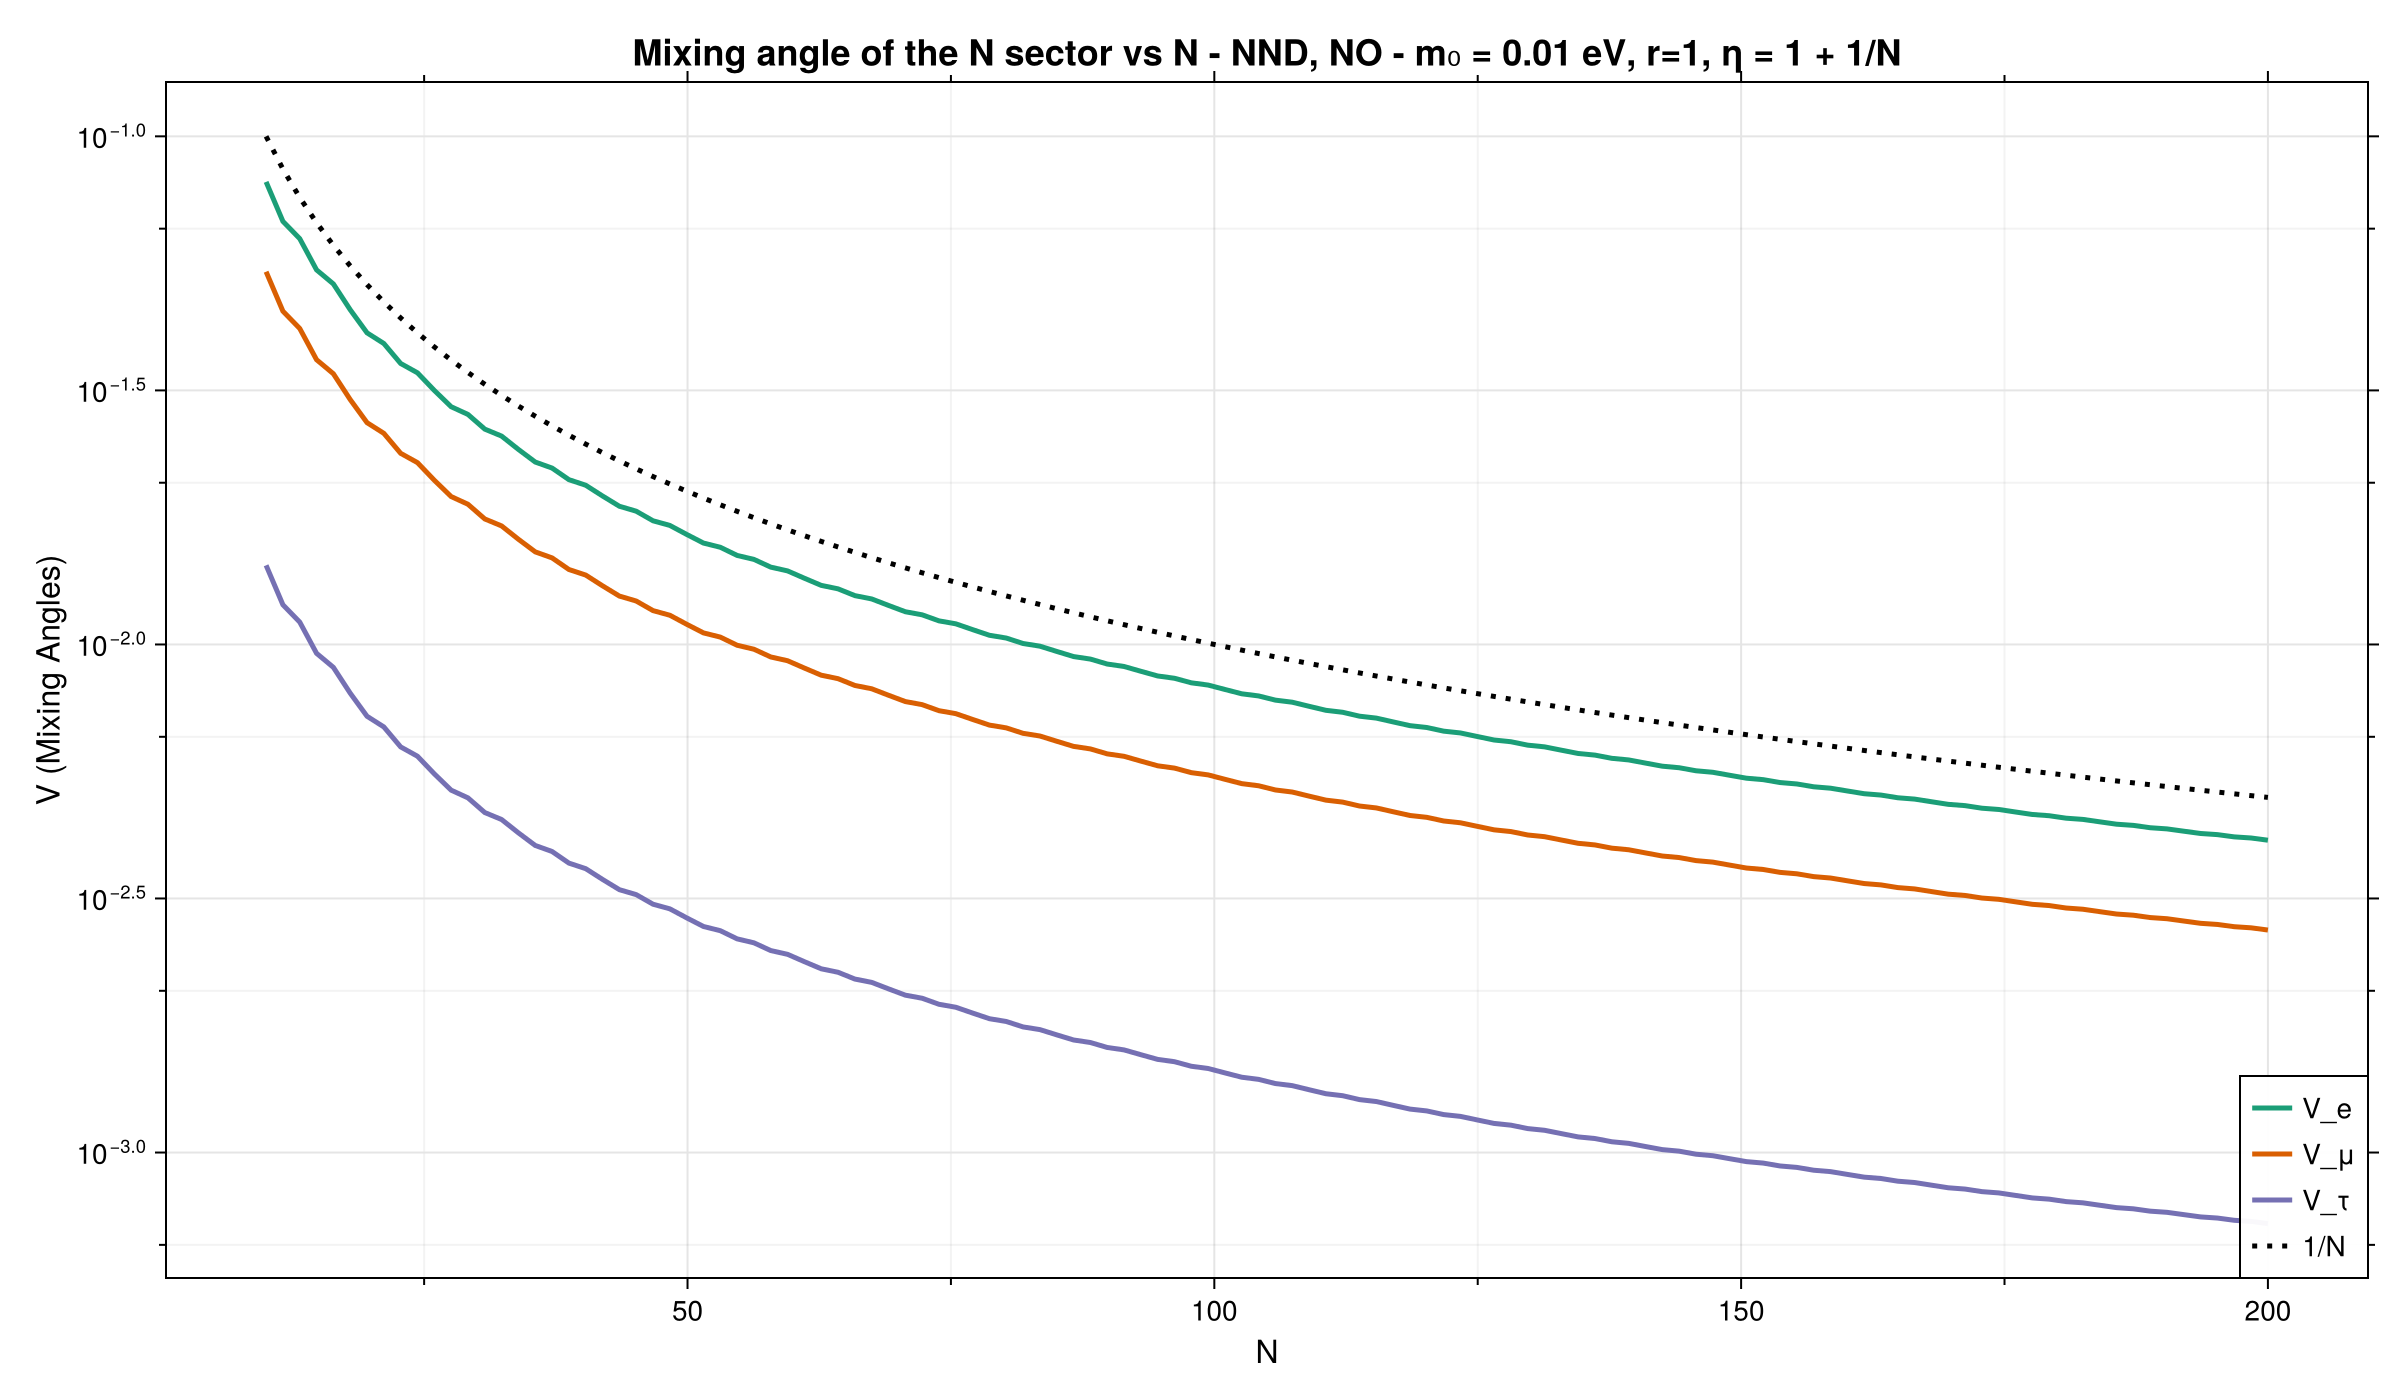

CairoMakie.Screen{SVG}


In [56]:
N_range  = range(10, 200, length = 120)

angles_e_list = []
angles_m_list = []
angles_t_list = []  

mass_e_list = []
mass_m_list = []
mass_t_list = []

cont_e_list = []
cont_m_list = []
cont_t_list = []

for N in N_range
    par_p = merge(par, (m₀ = 0.01, r = 1, N = N))
    mass_e, mass_m, mass_t, angles_e, angles_m, angles_t = Newtrinos.katrin.mixing_angles(par_p, osc_cfg.flavour)
    angles_e = angles_e[Int(round(end))]
    angles_m = angles_m[Int(round(end))]
    angles_t = angles_t[Int(round(end))]
    mass_e = mass_e[Int(round(end))]
    mass_m = mass_m[Int(round(end))]
    mass_t = mass_t[Int(round(end))]
    cont_e = mass_e .* (angles_e).^2
    cont_m = mass_m .* (angles_m).^2
    cont_t = mass_t .* (angles_t).^2

    push!(angles_e_list, angles_e)
    push!(angles_m_list, angles_m)
    push!(angles_t_list, angles_t)
    push!(mass_e_list, mass_e)
    push!(mass_m_list, mass_m)  
    push!(mass_t_list, mass_t)
    push!(cont_e_list, cont_e)
    push!(cont_m_list, cont_m)
    push!(cont_t_list, cont_t)
end

using CairoMakie
using ColorSchemes
# ===================== COLORS =====================

cs = ColorSchemes.Dark2_8
c_e = cs[1]
c_m = cs[2]
c_t = cs[3]
c_lim = :black

# ===================== FIGURE 1: MIXING ANGLES (V) =====================
fig1 = Figure(size=(1200, 700))
ax1 = Axis(
    fig1[1, 1],
    title = "Mixing angle of the N sector vs N - NND, NO - m₀ = 0.01 eV, r=1, η = 1 + 1/N",
    xlabel = "N",
    ylabel = "V (Mixing Angles)",
   # xscale = log10,
    yscale = log10,
    xminorticksvisible = true,
    xminorgridvisible = true,
    yminorticksvisible = true,
    yminorgridvisible = true,
    titlesize = 18,
    xlabelsize = 16,
    ylabelsize = 16,
    xticklabelsize = 14,
    yticklabelsize = 14,
    xgridvisible = true,
    ygridvisible = true,
    xgridcolor = :gray90,
    ygridcolor = :gray90,
    xticksmirrored = true,
    yticksmirrored = true
)

lines!(ax1, N_range, [angles_e_list[i] for i in 1:length(N_range)]; color = c_e, linewidth = 2.5, label = "V_e")
lines!(ax1, N_range, [angles_m_list[i] for i in 1:length(N_range)]; color = c_m, linewidth = 2.5, linestyle=:solid, label = "V_mu")
lines!(ax1, N_range, [angles_t_list[i] for i in 1:length(N_range)]; color = c_t, linewidth = 2.5, linestyle=:solid, label = "V_tau")
lines!(ax1, N_range, [1/(N_range[i]) for i in 1:length(N_range)]; color = c_lim, linewidth = 2.5, linestyle=:dot, label = "1/N")

Legend(
    fig1[1,1],
    [
        LineElement(color = c_e, linewidth = 2.5, linestyle = :solid),
        LineElement(color = c_m, linewidth = 2.5, linestyle = :solid),
        LineElement(color = c_t, linewidth = 2.5, linestyle = :solid),
       LineElement(color = c_lim, linewidth = 2.5, linestyle = :dot),
    ],
    [
        "V_e", "V_μ", "V_τ", "1/N"
    ];
    tellwidth = false,
    tellheight = false,
    halign = :right,
    valign = :bottom,
    labelsize = 14,
    framevisible = true,
    backgroundcolor = (:white, 0.95),
    strokecolor = :black,
    strokewidth = 0.5,
    title = "Legend",
    titlefont = :bold,
    titlesize = 16
)

display("image/png", fig1)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/katrin_NND_NO_angles_N.png", fig1)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/katrin_NND_NO_angles_N.svg", fig1) 


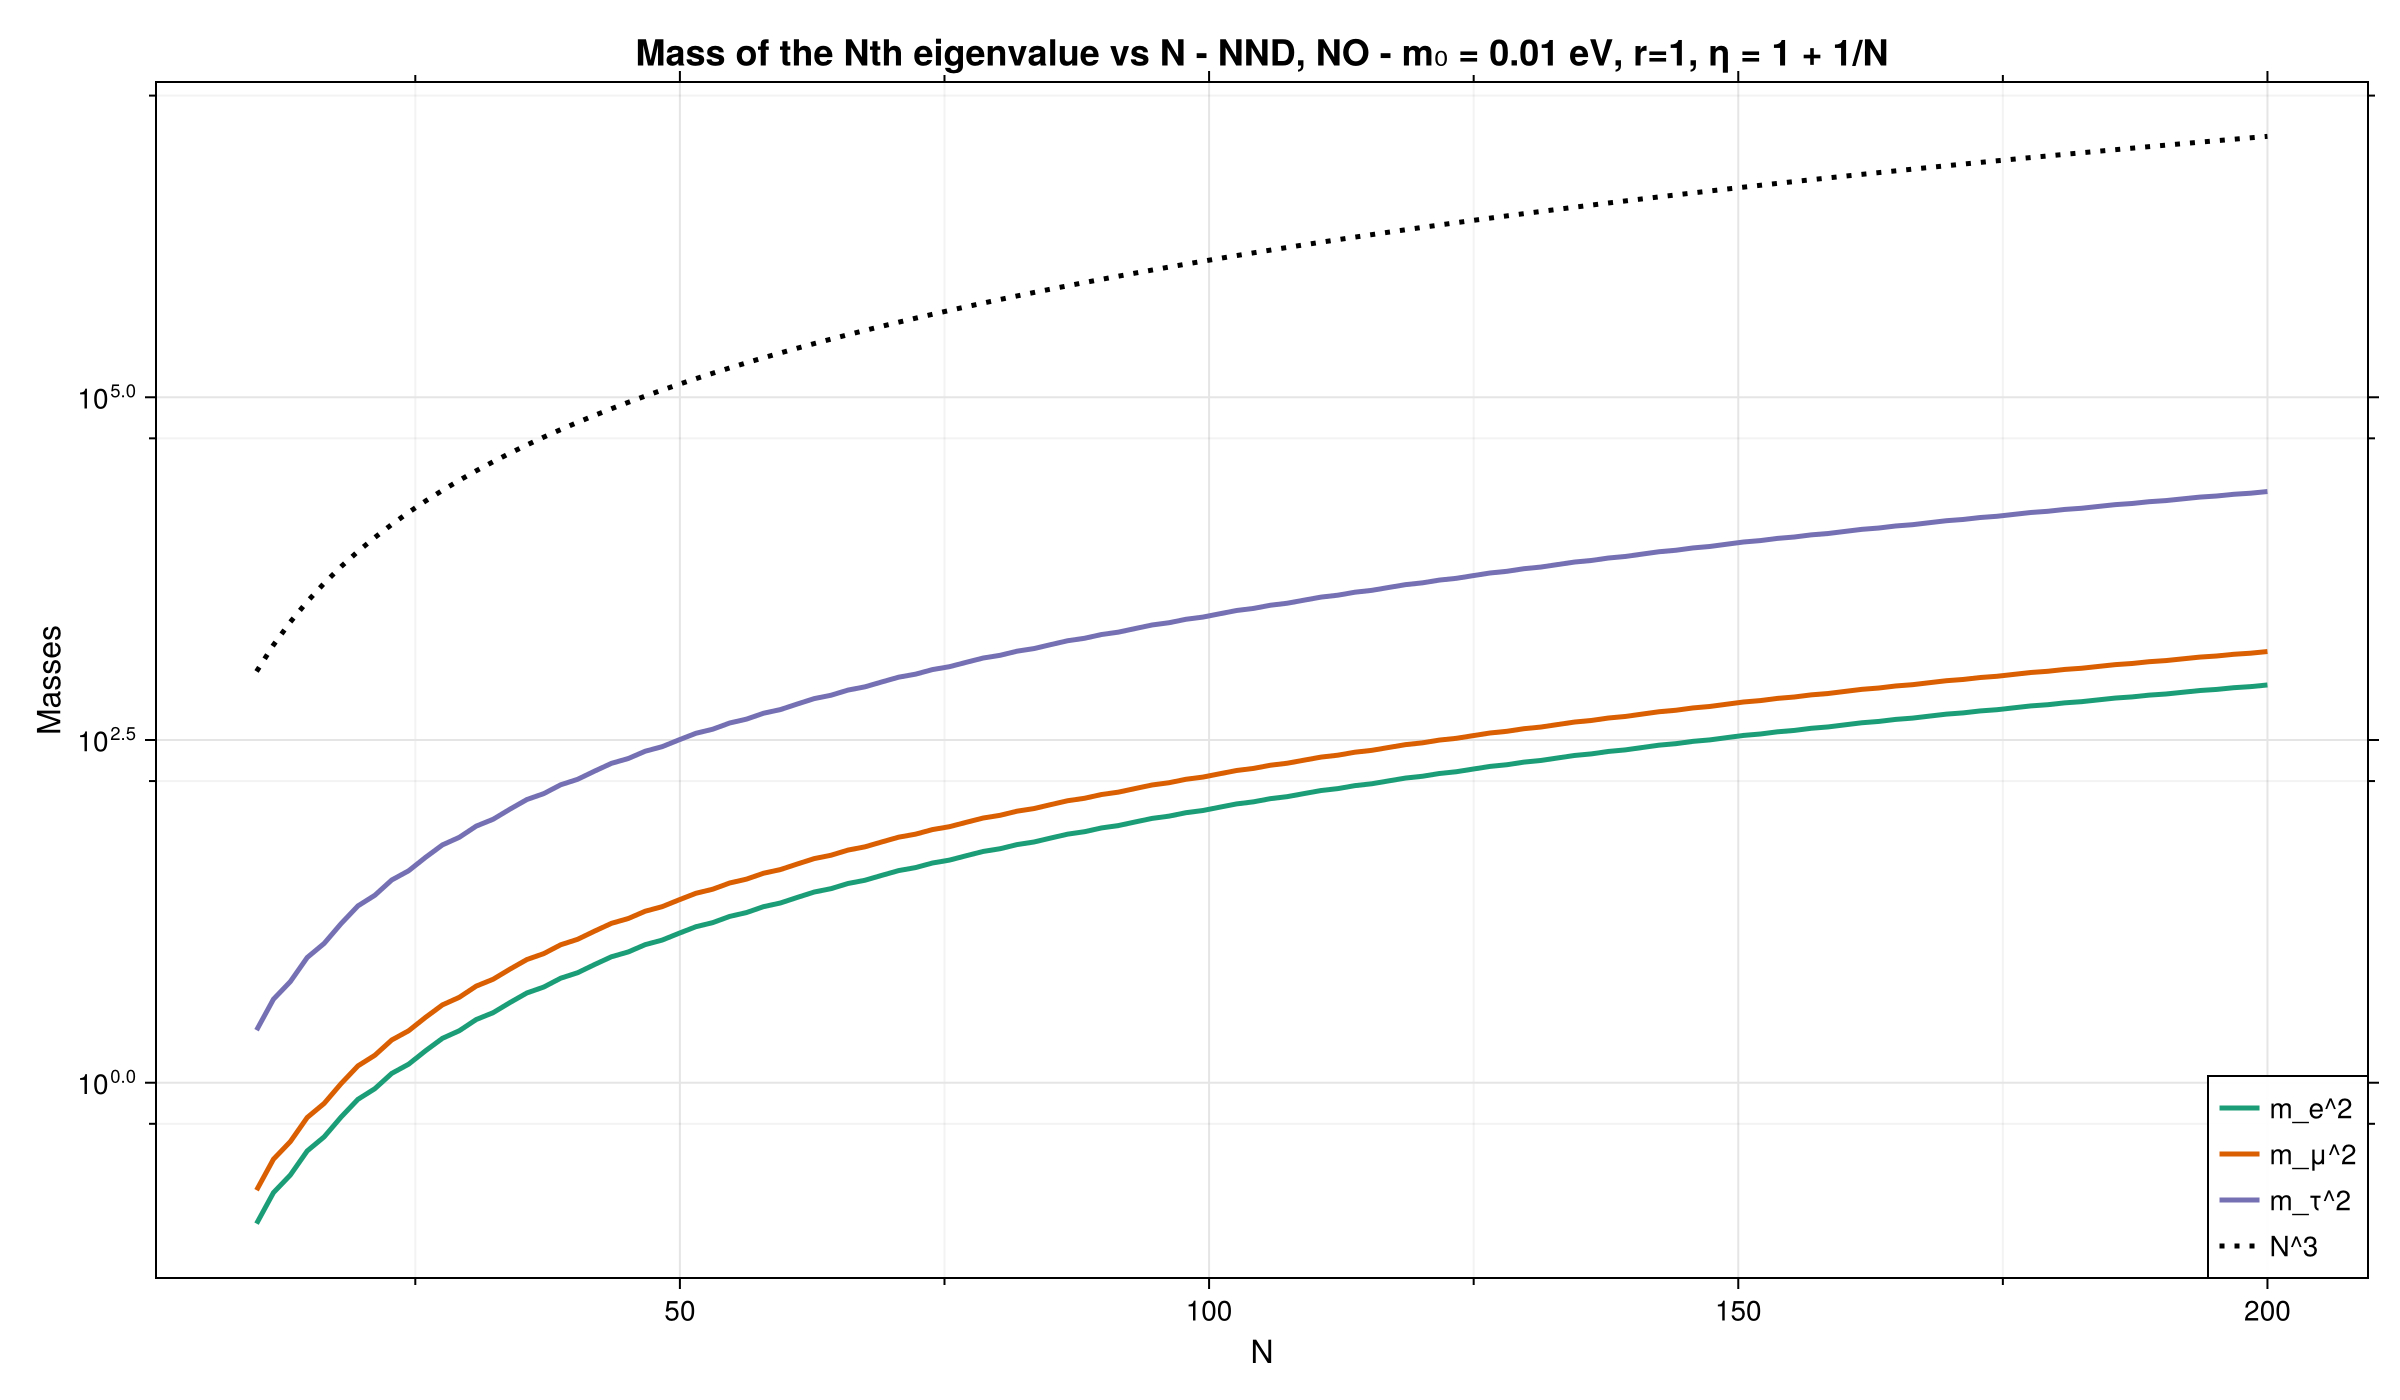

CairoMakie.Screen{SVG}


In [57]:

# ===================== FIGURE 2: MASSES =====================
fig2 = Figure(size=(1200, 700))
ax2 = Axis(
    fig2[1, 1],
    title = "Mass of the Nth eigenvalue vs N - NND, NO - m₀ = 0.01 eV, r=1, η = 1 + 1/N",
    xlabel = "N",
    ylabel = "Masses",
    #xscale = log10,
    yscale = log10,
    xminorticksvisible = true,
    xminorgridvisible = true,
    yminorticksvisible = true,
    yminorgridvisible = true,
    titlesize = 18,
    xlabelsize = 16,
    ylabelsize = 16,
    xticklabelsize = 14,
    yticklabelsize = 14,
    xgridvisible = true,
    ygridvisible = true,
    xgridcolor = :gray90,
    ygridcolor = :gray90,
    xticksmirrored = true,
    yticksmirrored = true
)

lines!(ax2, N_range, [mass_e_list[i] for i in 1:length(N_range)]; color = c_e, linewidth = 2.5, label = "m_e")
lines!(ax2, N_range, [mass_m_list[i] for i in 1:length(N_range)]; color = c_m, linewidth = 2.5, linestyle=:solid, label = "m_mu")
lines!(ax2, N_range, [mass_t_list[i] for i in 1:length(N_range)]; color = c_t, linewidth = 2.5, linestyle=:solid, label = "m_tau")
lines!(ax2, N_range, [(N_range[i]^3) for i in 1:length(N_range)]; color = c_lim, linewidth = 2.5, linestyle=:dot, label = "N^3")
Legend(
    fig2[1,1],
    [
        LineElement(color = c_e, linewidth = 2.5, linestyle = :solid),
        LineElement(color = c_m, linewidth = 2.5, linestyle = :solid),
        LineElement(color = c_t, linewidth = 2.5, linestyle = :solid),
        LineElement(color = c_lim, linewidth = 2.5, linestyle = :dot),  
    ],
    [
        "m_e^2", "m_μ^2","m_τ^2", "N^3"
    ];
    tellwidth = false,
    tellheight = false,
    halign = :right,
    valign = :bottom,
    labelsize = 14,
    framevisible = true,
    backgroundcolor = (:white, 0.95),
    strokecolor = :black,
    strokewidth = 0.5,
    title = "Legend",
    titlefont = :bold,
    titlesize = 16
)

display("image/png", fig2)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/katrin_NND_NO_masses_N.png", fig2)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/katrin_NND_NO_masses_N.svg", fig2) 


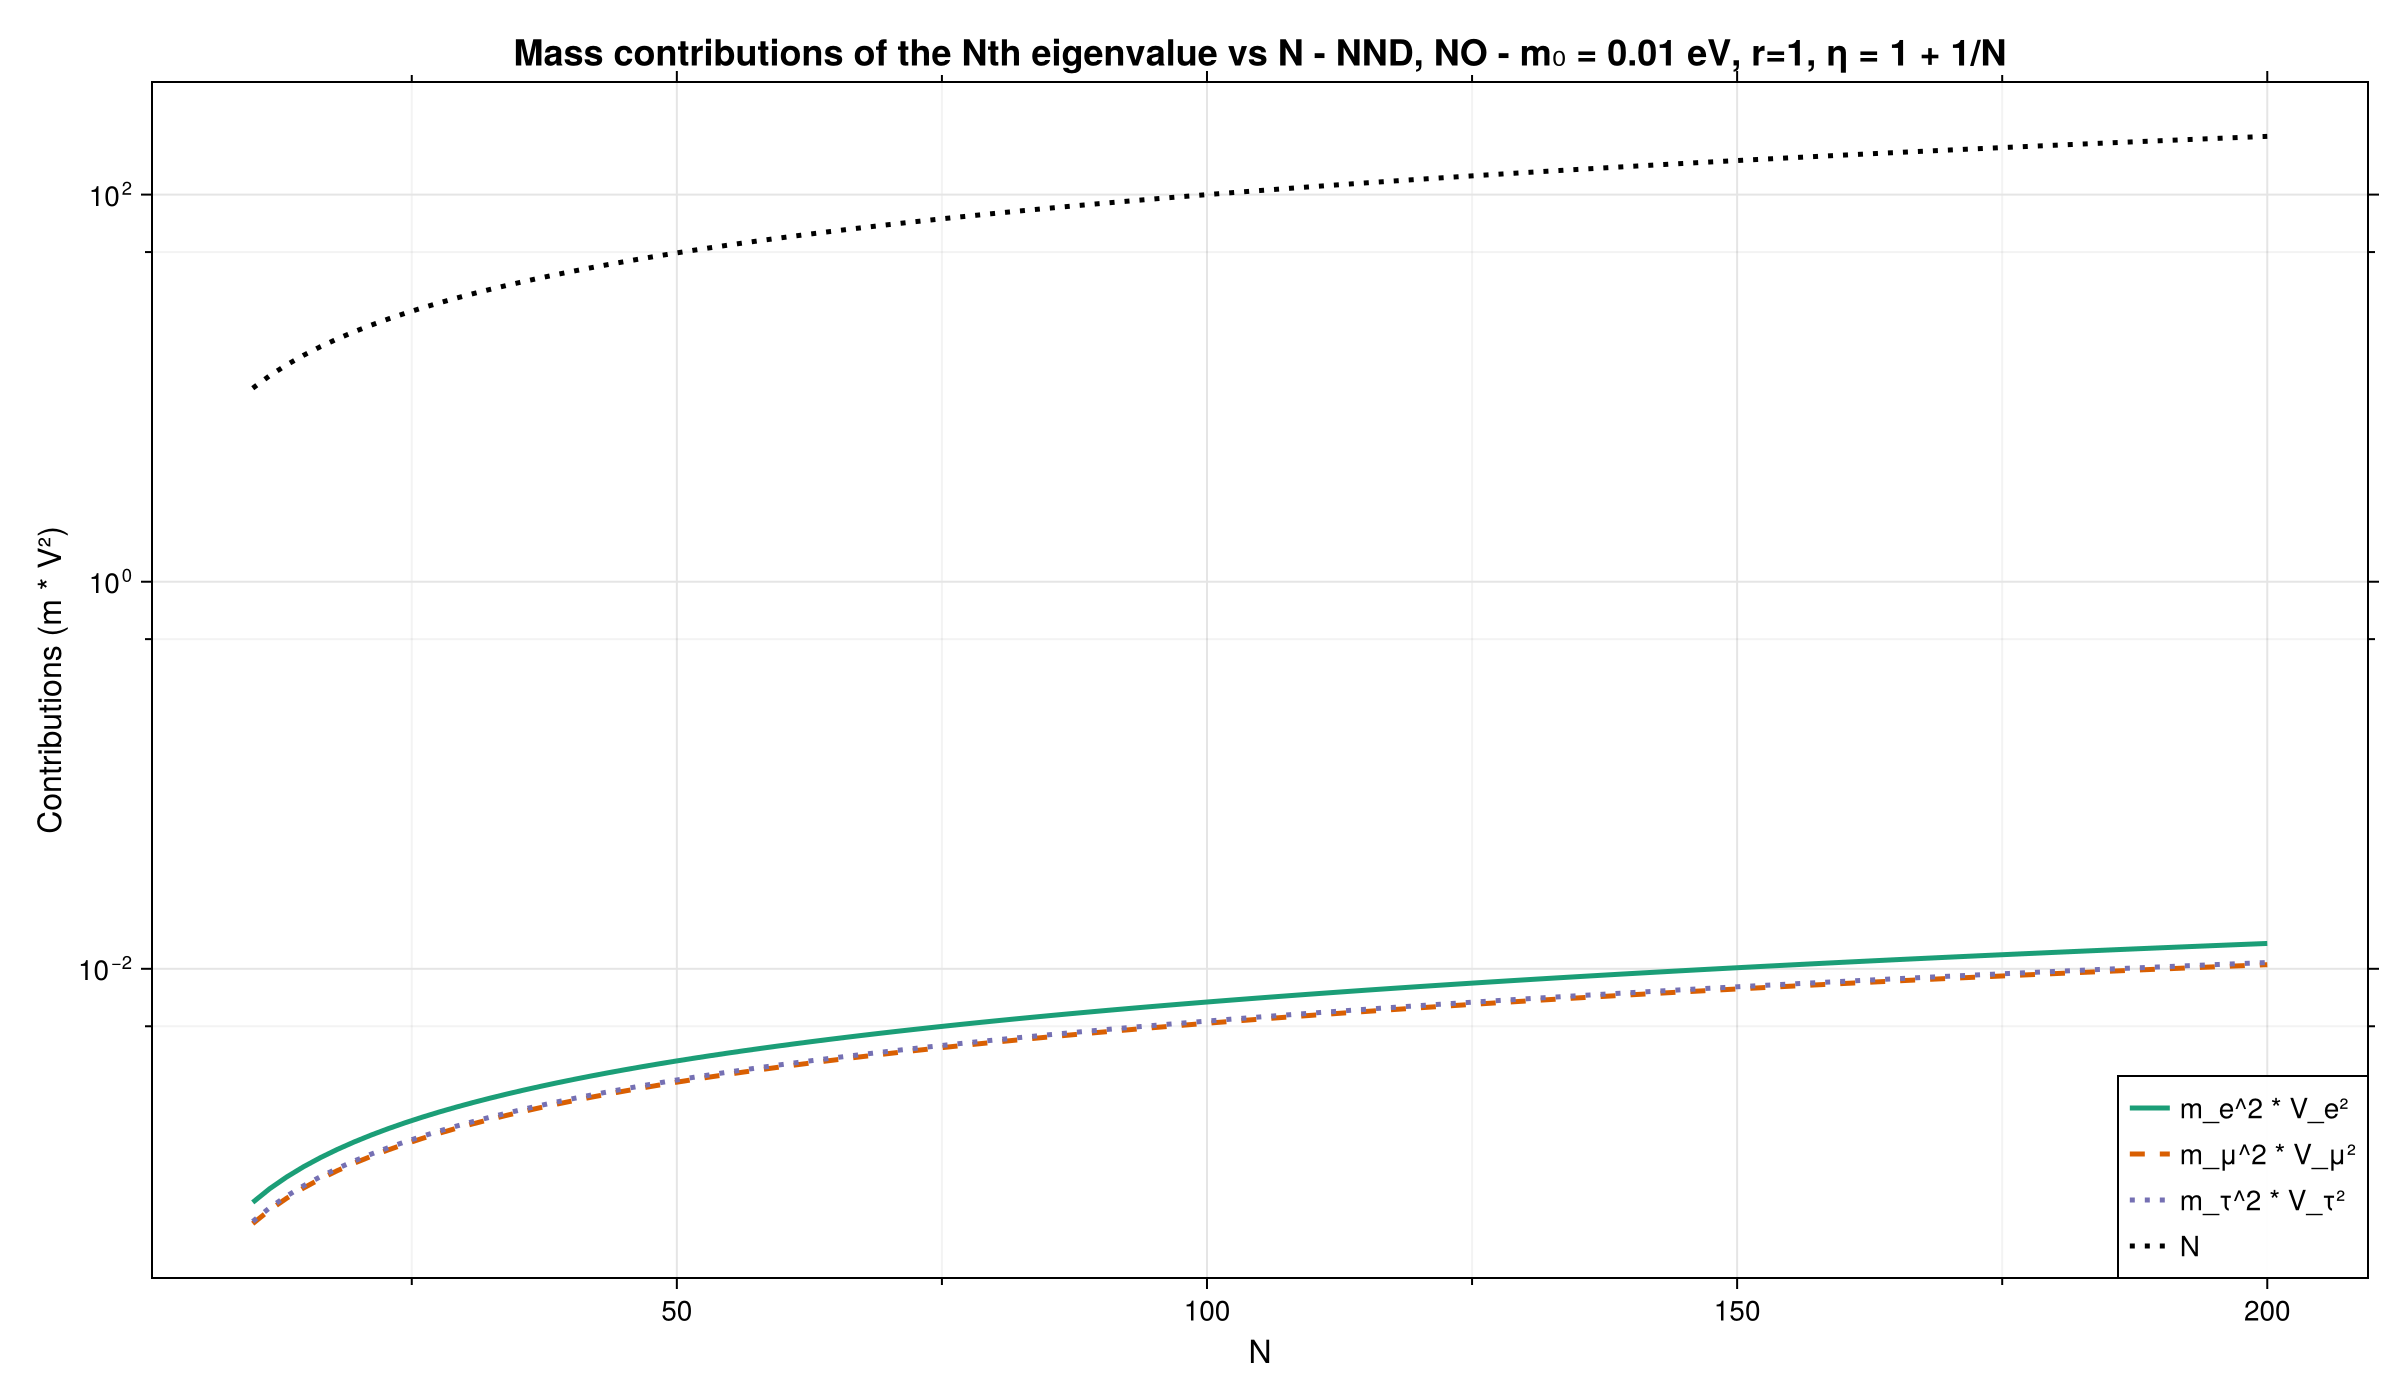

CairoMakie.Screen{SVG}


In [58]:

# ===================== FIGURE 3: CONTRIBUTIONS =====================
fig3 = Figure(size=(1200, 700))
ax3 = Axis(
    fig3[1, 1],
    title = "Mass contributions of the Nth eigenvalue vs N - NND, NO - m₀ = 0.01 eV, r=1, η = 1 + 1/N",
    xlabel = "N",
    ylabel = "Contributions (m * V²)",
    #xscale = log10,
    yscale = log10,
    xminorticksvisible = true,
    xminorgridvisible = true,
    yminorticksvisible = true,
    yminorgridvisible = true,
    titlesize = 18,
    xlabelsize = 16,
    ylabelsize = 16,
    xticklabelsize = 14,
    yticklabelsize = 14,
    xgridvisible = true,
    ygridvisible = true,
    xgridcolor = :gray90,
    ygridcolor = :gray90,
    xticksmirrored = true,
    yticksmirrored = true
)

lines!(ax3, N_range, [cont_e_list[i] for i in 1:length(N_range)]; color = c_e, linewidth = 2.5, label = "m_e * V_e²")
lines!(ax3, N_range, [cont_m_list[i] for i in 1:length(N_range)]; color = c_m, linewidth = 2.5, linestyle=:dash, label = "m_mu * V_mu²")
lines!(ax3, N_range, [cont_t_list[i] for i in 1:length(N_range)]; color = c_t, linewidth = 2.5, linestyle=:dot, label = "m_tau * V_tau²")
lines!(ax3, N_range, [(N_range[i]) for i in 1:length(N_range)]; color = c_lim, linewidth = 2.5, linestyle=:dot, label = "N")

Legend(
    fig3[1,1],
    [
        LineElement(color = c_e, linewidth = 2.5, linestyle = :solid),
        LineElement(color = c_m, linewidth = 2.5, linestyle = :dash),
        LineElement(color = c_t, linewidth = 2.5, linestyle = :dot),
        LineElement(color = c_lim, linewidth = 2.5, linestyle = :dot),
    ],
    [
        "m_e^2 * V_e²", "m_μ^2 * V_μ²", "m_τ^2 * V_τ²", "N"
    ];
    tellwidth = false,
    tellheight = false,
    halign = :right,
    valign = :bottom,
    labelsize = 14,
    framevisible = true,
    backgroundcolor = (:white, 0.95),
    strokecolor = :black,
    strokewidth = 0.5,
    title = "Legend",
    titlefont = :bold,
    titlesize = 16
)

display("image/png", fig3)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/katrin_NND_NO_contributions_N.png", fig3)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/katrin_NND_NO_contributions_N.svg", fig3) 

In [67]:

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel =  "i - number of sector",
    ylabel = "Matrix elements UV_ij",
    title = "Mixing matrix elements UV_ij - Katrin NND NO",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

i_range=1:length(angles_e)
# Plot the main curve
lines!(ax, i_range, abs.(angles_e),
    color = :green,
    linewidth = 2,
    label = "M_ei"
)

lines!(ax, i_range, abs.(angles_m),
    color = :blue,
    linewidth = 2,
    label = "M_mi"
)

lines!(ax, i_range, abs.(angles_t),
    color = :purple,
    linewidth = 2,
    label = "M_ti"
)

lines!(ax, i_range, abs.(angles_t),
    color = :purple,
    linewidth = 2,
    label = "M_ti"
)
# Add legend
axislegend(ax, position = :rt)  # right bottom

#save("/home/sofialon/Newtrinos.jl/plot_final/katrin_checks/matrix_elements_N=100_m0=0.1_r=1.png", fig)

display("image/png", fig)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


LoadError: ArgumentError:     Conversion failed for Lines (With conversion trait PointBased()) with args: Tuple{UnitRange{Int64}, Float64} .
    Lines requires to convert to argument types Tuple{AbstractVector{<:Union{Point2, Point3}}}, which convert_arguments didn't succeed in.
    To fix this overload convert_arguments(P, args...) for Lines or PointBased() and return an object of type Tuple{AbstractVector{<:Union{Point2, Point3}}}.`


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


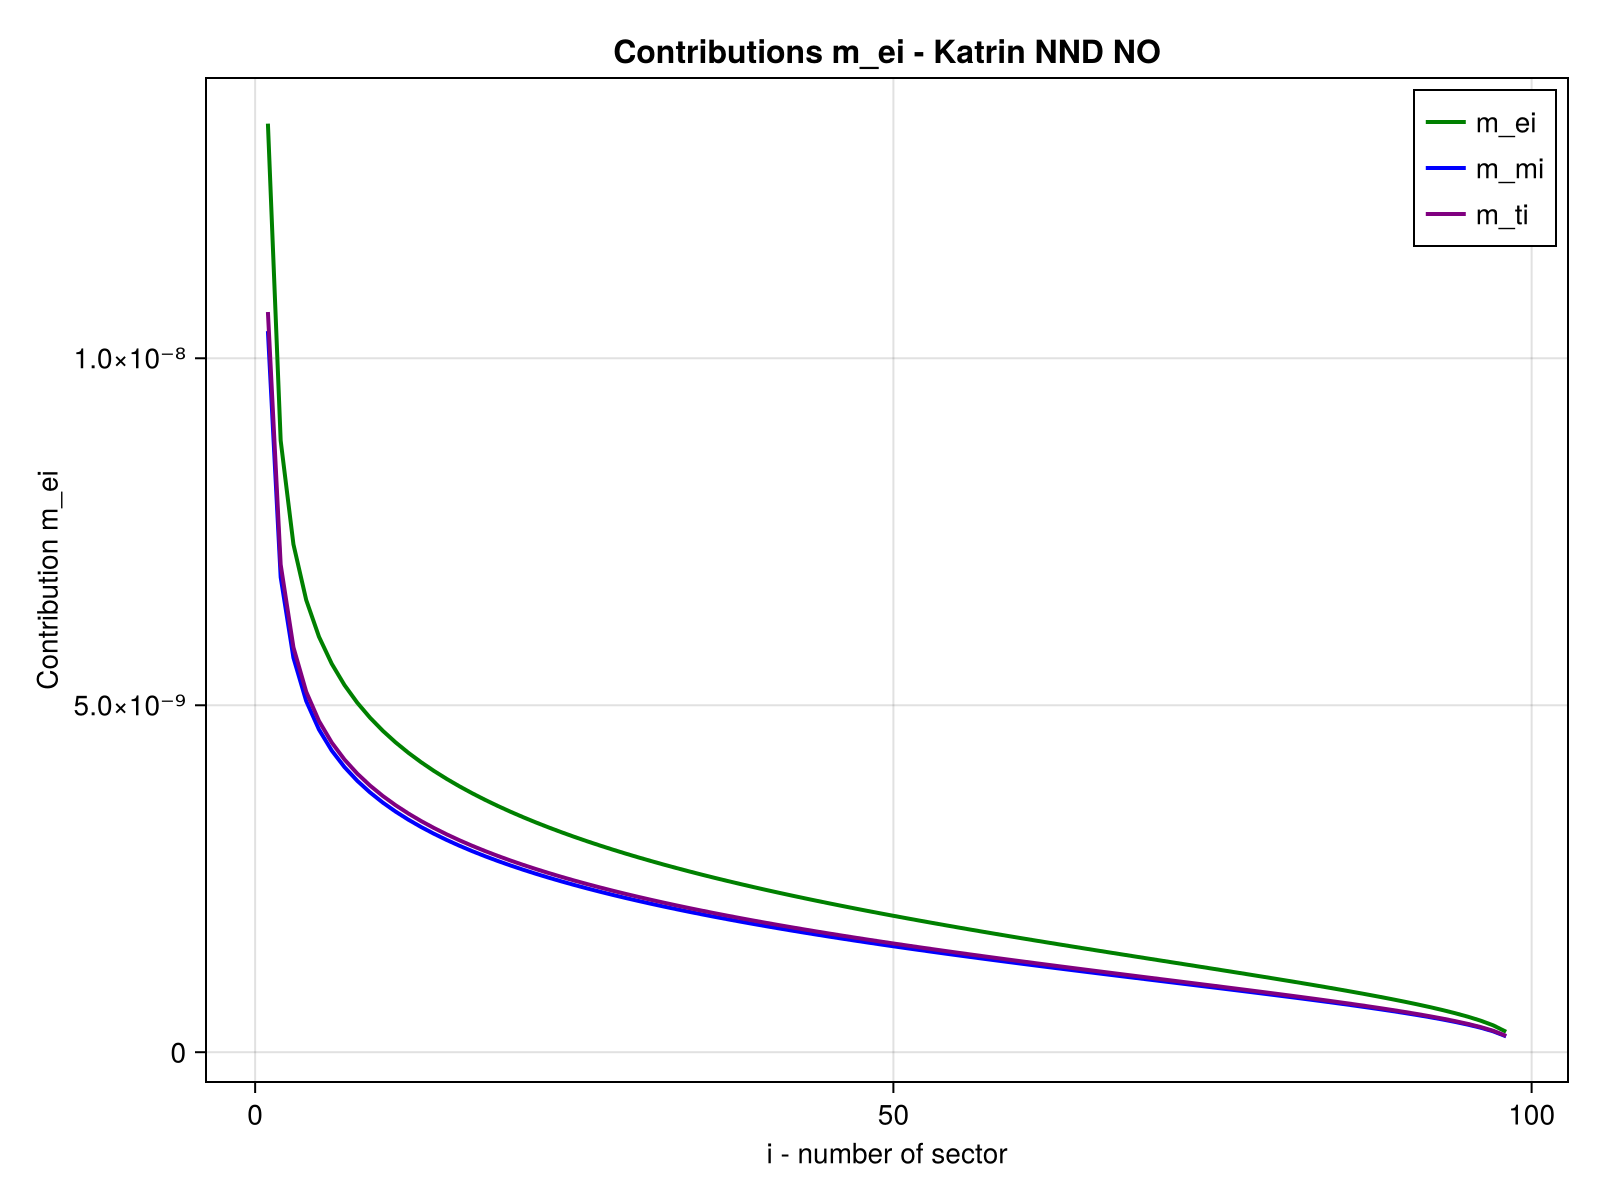

In [ ]:

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel =  "i - number of sector",
    ylabel = "Contribution m_ei",
    title = "Contributions m_ei - Katrin NND NO",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

i_range=1:length(angles_e)
# Plot the main curve
lines!(ax, i_range, cont_e,
    color = :green,
    linewidth = 2,
    label = "m_ei"
)

lines!(ax, i_range, cont_m,
    color = :blue,
    linewidth = 2,
    label = "m_mi"
)

lines!(ax, i_range, cont_t,
    color = :purple,
    linewidth = 2,
    label = "m_ti"
)
# Add legend
axislegend(ax, position = :rt)  # right bottom

#save("/home/sofialon/Newtrinos.jl/plot_final/katrin_checks/m_contributions_N=100_m0=0.1_r=1.png", fig)


display("image/png", fig)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


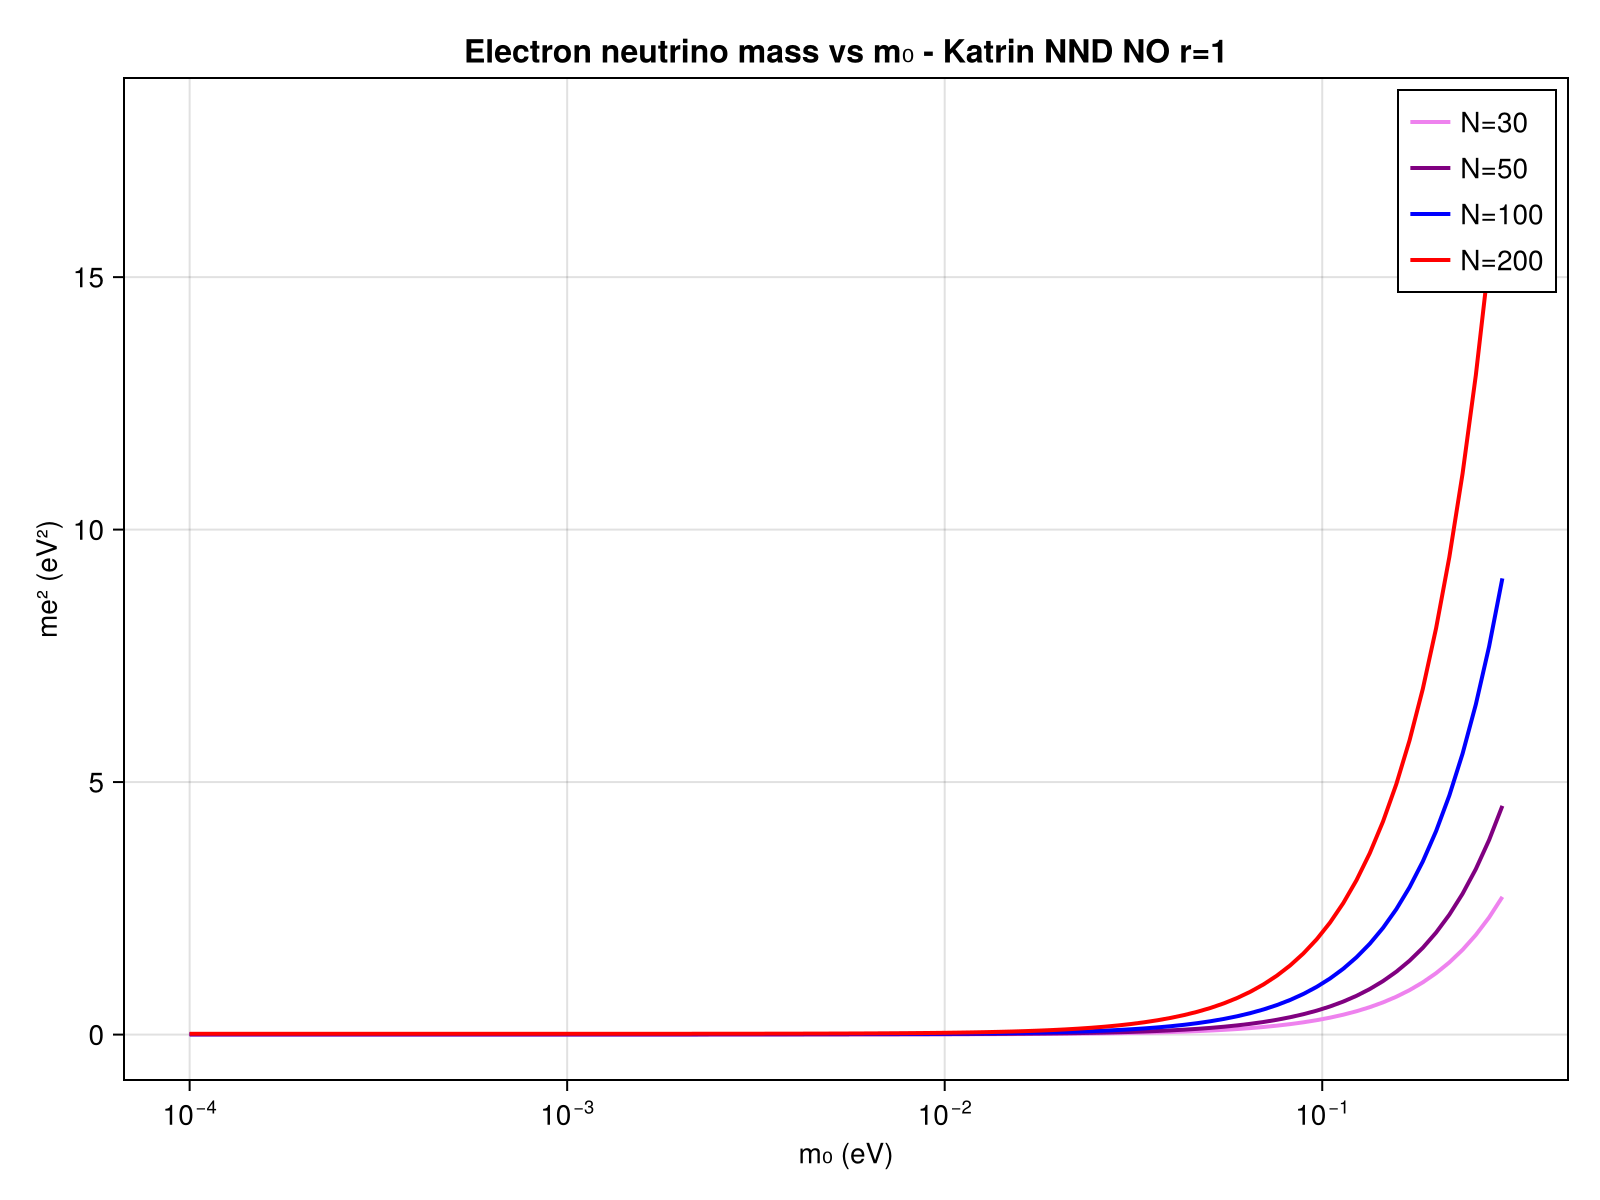

In [ ]:
m0_range= logrange(1e-4, 0.3, 100)

mass_nu_0=[]
mass_nu_1=[]
mass_nu_2=[]
mass_nu_3=[]

for m in m0_range

    par_p= merge(par, (m₀=m, r=1, N=30))   
    mass = Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_0, mass)
    
end    

for m in m0_range

    par_p= merge(par, (m₀=m, r=1, N=50))   
    mass = Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_1, mass)
    
end    

for m in m0_range

    par_p= merge(par, (m₀=m, r=1, N=100))   
    mass = Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_2, mass)
    
end    


for m in m0_range

    par_p= merge(par, (m₀=m, r=1, N=200))   
    mass = Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_3, mass)
    
end    


# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
   xlabel = "m₀ (eV)",
   ylabel = "me² (eV²)",
    title = "Electron neutrino mass vs m₀ - Katrin NND NO r=1",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14, 
    xscale = log10
)


# Plot the main curve
lines!(ax, m0_range, mass_nu_0,
    color = :violet,
    linewidth = 2,
    label = "N=30"
)


# Plot the main curve
lines!(ax, m0_range, mass_nu_1,
    color = :purple,
    linewidth = 2,
    label = "N=50"
)

lines!(ax, m0_range, mass_nu_2,
    color = :blue,
    linewidth = 2,
    label = "N=100"
)

lines!(ax, m0_range, mass_nu_3,
    color = :red,
    linewidth = 2,
    label = "N=200"
)

axislegend(ax, position = :rt) 
#save("/home/sofialon/Newtrinos.jl/plots_NP/katrin_checks/me_m0_NND_NO.png", fig)


display("image/png", fig)

In [ ]:

#m0_range= LinRange(1e-6, 1e-4, 100)
r_range=LinRange(0, 1.0, 100)

angles_e_r=[]
angles_m_r=[]
angles_t_r=[]

cont_e_r=[]
cont_m_r=[]
cont_t_r=[]

for r in r_range
    
    par_new = merge(par, (m₀=0.01, r=r, N=100))    
    mass_e, mass_m, mass_t, angles_e, angles_m, angles_t = Newtrinos.katrin.mixing_angles( par_new, osc_cfg.flavour)

    
    cont_e=mass_e.*(angles_e).^2
    cont_m=mass_m.*(angles_m).^2
    cont_t=mass_t.*(angles_t).^2


    push!(angles_e_r, angles_e[1])
    push!(angles_m_r, angles_m[1])
    push!(angles_t_r, angles_t[1])


    push!(cont_e_r, cont_e[1] )
    push!(cont_m_r, cont_m[1] )
    push!(cont_t_r, cont_t[1] )
end




┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


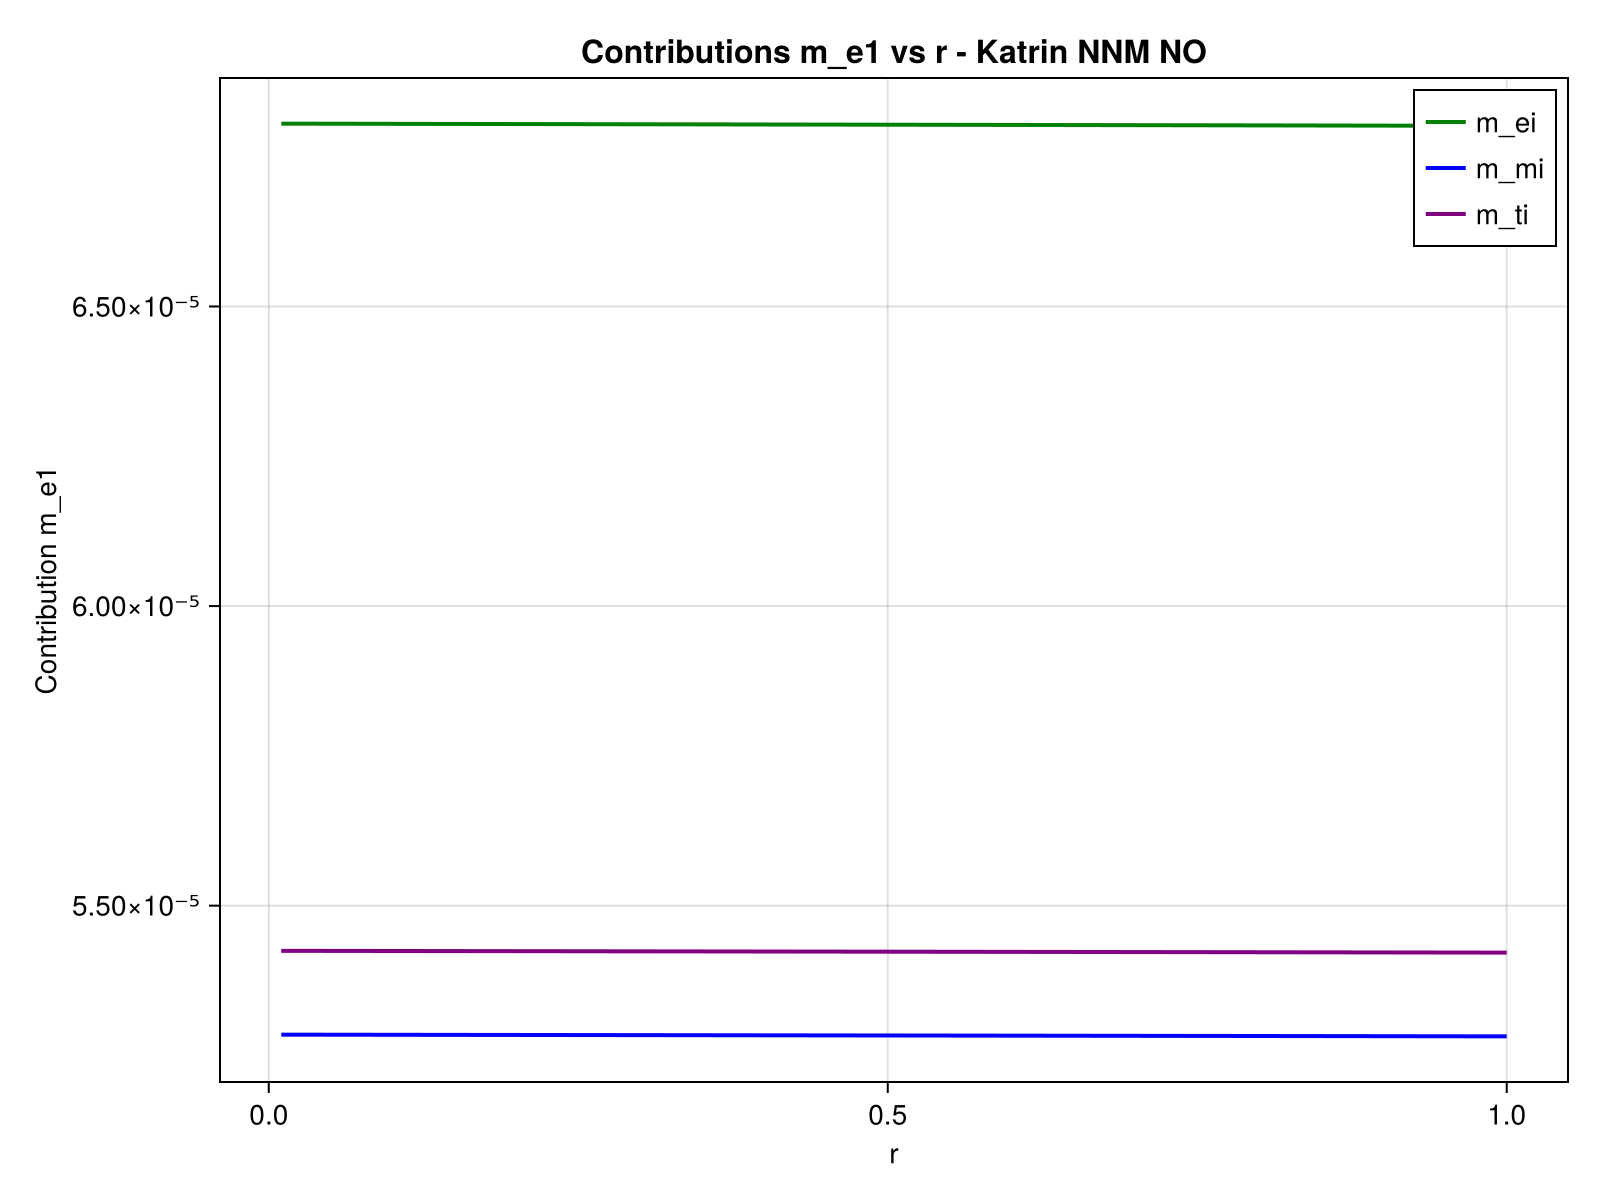

In [ ]:

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel =  "r",
    ylabel = "Contribution m_e1",
    title = "Contributions m_e1 vs r - Katrin NND NO",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

# Plot the main curve
lines!(ax, r_range, cont_e_r,
    color = :green,
    linewidth = 2,
    label = "m_ei"
)

lines!(ax, r_range, cont_m_r,
    color = :blue,
    linewidth = 2,
    label = "m_mi"
)

lines!(ax, r_range, cont_t_r,
    color = :purple,
    linewidth = 2,
    label = "m_ti"
)
# Add legend
axislegend(ax, position = :rt)  # right bottom

#save("/home/sofialon/Newtrinos.jl/plot_final/katrin_checks/m_contributions_N=100_m0=0.00001_1eigen.png", fig)


display("image/png", fig)

Naive plotting to check

In [ ]:
#predicted values comparison

using Revise
using Newtrinos
using Newtrinos.osc

m0_range= LinRange(1e-6, 1e-4, 100)
r_range=LinRange(0, 1.0, 100)

predicted=[]

for m₀ in m0_range
    for r in r_range
        par_new = merge(par, (m₀=m₀, r=r, N=100))    
        pred, twosigma = Newtrinos.katrin.comparing_masses(osc_cfg.flavour, experiments, par_new)
        push!(predicted, pred)
    end
end

predicted[100]


In [ ]:
#plotting
observed_dist = Normal(experiments.katrin.assets.observed, 0.13)
observed_mean = mean(observed_dist)
observed_sigma = std(observed_dist)

# Create 2D grid for plotting
n_m0 = length(m0_range)
n_r = length(r_range)

# Reshape predicted values into 2D array
predicted_2d = reshape(predicted, n_r, n_m0)

lower_bound = observed_mean - 2 * observed_sigma
upper_bound = observed_mean + 2* observed_sigma

within_2sigma = (predicted_2d .>= lower_bound) .& (predicted_2d .<= upper_bound)


# Create the plot
fig = Figure(size=(1000, 800))
ax = Axis(fig[1, 1],
    ylabel="m₀ (eV)",
    xlabel="r",
    title="Predicted Values: Within vs Outside 2-σ Range")

r_grid = repeat(r_range, n_m0)
m0_grid = repeat(m0_range, inner=n_r)

within_flat = vec(within_2sigma)


within_indices = findall(within_flat)
outside_indices = findall(.!within_flat)

r_within = r_grid[within_indices]
m0_within = m0_grid[within_indices]

r_outside = r_grid[outside_indices]
m0_outside = m0_grid[outside_indices]

# Plot scatter points
scatter!(ax, r_within, m0_within, 
    color=:blue, 
    markersize=10, 
    label="Within 2-σ",
    alpha=0.7)

scatter!(ax, r_outside, m0_outside, 
    color=:green, 
    markersize=10, 
    label="Outside 2-σ",
    alpha=0.7)


display(fig)


In [ ]:
using Revise
using Newtrinos
using Newtrinos.osc

N_range= LinRange(1, 50, 100)
r_range=LinRange(0, 1.0, 100)

predicted=[]

for N in N_range
    for r in r_range
        par_new = merge(par, (N=N, r=r))    
        pred, twosigma = Newtrinos.katrin.comparing_masses(osc_cfg.flavour, experiments, par_new)
        push!(predicted, pred)
    end
end

predicted[100]

In [ ]:
#plotting
observed_dist = Normal(experiments.katrin.assets.observed, 0.13)
observed_mean = mean(observed_dist)
observed_sigma = std(observed_dist)

# Create 2D grid for plotting
n_N = length(N_range)
n_r = length(r_range)

# Reshape predicted values into 2D array
predicted_2d = reshape(predicted, n_r, n_N)

lower_bound = observed_mean - 2 * observed_sigma
upper_bound = observed_mean + 2 * observed_sigma

within_2sigma = (predicted_2d .>= lower_bound) .& (predicted_2d .<= upper_bound)


# Create the plot
fig1 = Figure(size=(1000, 800))
ax = Axis(fig1[1, 1],
    ylabel="N",
    xlabel="r",
    title="Predicted Values: Within vs Outside 2-σ Range")

# Create meshgrid of r and N values
r_grid = repeat(r_range, n_N)
N_grid = repeat(N_range, inner=n_r)

# Flatten the within_2sigma matrix
within_flat = vec(within_2sigma)

# Separate points into two groups
within_indices = findall(within_flat)
outside_indices = findall(.!within_flat)

r_within = r_grid[within_indices]
N_within = N_grid[within_indices]

r_outside = r_grid[outside_indices]
N_outside = N_grid[outside_indices]

# Plot scatter points
scatter!(ax, r_within, N_within, 
    color=:blue, 
    markersize=10, 
    label="Within 2-σ",
    alpha=0.7)

scatter!(ax, r_outside, N_outside, 
    color=:green, 
    markersize=10, 
    label="Outside 2-σ",
    alpha=0.7)


display(fig1)
